# Master Project – Preliminary Analysis of Random Directed Networks

---
**Author:** Thomas Rey  
**Supervisor:** Matúš Medo    
**Date of creation:** 26 September 2025  

_**Objective**: Set up the basis for the project using random directed networks, by implementing the first steps described in the email (17.09.2025)_

**Estimated runtime**: about 6-8 minutes on a standard laptop (with the .pkl files)

**Unusual library used:** tqdm / os / pickle

---

In [147]:
import time 
start = time.time()

In [148]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## 1. Random directed networks

_Goal: creation of a function generating a directed network where the edges are chosen randomly between the nodes, as well as their direction._  

**Inputs of the function**: number of nodes ($N$) and number of edges ($E$)

In [149]:
def generate_random_network(N,E, draw=False):
    """
    Generates a random directed network with N nodes and E edges, 
    where the links between nodes and their directions are randomly assigned.

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        draw (bool): If True, the network is drawn (default: False).

    Returns:
        G (DiGraph (from NetworkX)) : A directed graph corresponding to the generated random network.
        
    """
    #check if the number of edges asked is possible 
    if E>N*(N-1): 
        raise ValueError(f"The maximum number of directed edges with {N} nodes is {N*(N-1)}.")

    #creation of the graph with N nodes
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    #creation of the edges by randomly choosing E edges from the list of all possibles edges (no self-loop)
    all_edges = [(i,j) for i in range(N) for j in range(N) if i!=j]
    
    chosen_indices = np.random.choice(len(all_edges), size=E, replace=False) #indices of the chosen edges, without replacement
    chosen_edges = [all_edges[i] for i in chosen_indices]
    G.add_edges_from(chosen_edges)

    #if asked, graph is drawn
    if draw:
        nx.draw_spring(G, with_labels=True)
        plt.show()

    return G

# example
# generate_random_network(20, 12, draw=True)
# nx.gnm_random_graph(5, 20, directed=True)

After implementing this function, I just realized that `nx.gnm_random_graph(N, E, directed=True)` provides the same result. For the following, we will use this predefined function. Writing the implementation by myself was still a good exercise to get familiar with the basic concepts of the NetworkX library.

**Note**: In this random model, each directed edge between two nodes can appear at most once. Both directions are possible (e.g. 0->1 and 1->0), but multiple wins of the same player against the same opponent are not considered here. 

## 2. Node metrics - In-degree, PageRank, Zermelo strength

From the random directed network, we can compute 3 different metrics:

1. **In-degree**: It counts the number of incoming edges for each node of the network. In our context, it represents a "win". For node $i$, it can be defined as follows:
$\begin{equation} s^{in}_i=\sum_j e_{ji}\end{equation}$ 
with $e_{ji}=1$ if there is a directed edge from $j$ to $i$, and $e_{ji}=0$ otherwise. 



2. **PageRank**: It is defined recursively on the scores of the nodes pointing to it. For node $i$, it is expressed as:


$\begin{equation} P_i = (1-\alpha) \sum_{j: s^{out}_j > 0} P_j \frac{e_{ji}}{s^{out}_j}  + \frac{\alpha}{N} + \frac{1-\alpha}{N} \sum_{j: s^{out}_j = 0} P_j  \end{equation}$ 

where: 
- $s_j^{out}=\sum_k e_{jk} $ is the out-degree of node $j$
- $\alpha \in [0,1]$ is the _algorithm parameter_, also called _teleportation probability_ (typically, $\alpha = 0.15$)
- the last term accounts for the nodes without outgoing edges (called _dangling nodes_)


3. **Zermelo's node strength**: Each player $i$ is assigned a parameter $\pi_i>0$, corresponding to its strength. The probability $p_{ij}$ that player $i$ beats player $j$ is then given by the Bradley-Terry model with
$\begin{equation} p_{ij}=\frac{\pi_i}{\pi_i+\pi_j}. \end{equation}$

The Zermelo's node strengths $\pi_i$ are obtained through an iterative algorithm, called **Zermelo's algorithm**:

$\begin{equation} \pi_i' = \frac{\sum_j  e_{ji}}{\sum_j (e_{ij} + e_{ji})/(\pi_i + \pi_j)}  \end{equation}$


There also exists a faster version, which converges to the same solution:

$\begin{equation} \pi_i' = \frac{\sum_j e_{ji}\pi_j/(\pi_i + \pi_j)}{\sum_j e_{ij}/(\pi_i + \pi_j)} \end{equation}$

**Note**: The node strengths $\pi_i$ are updated using an $\underline{\text{asynchronous update procedure}}$ (more efficient than a synchronous update). The initial values of $\pi_i$ were chosen randomly such that the scores $s_i$ are drawn from a logistic distribution: 
\begin{equation} f(s) = \frac{1}{(e^s+1)(e^{-s}+1)} \end{equation}

with the relation $\pi_i = e^{s_i}$. 

(_Later on, we will consider weighted directed networks, and use $w_{ij}$ to denote the number of wins of player $i$ against player $j$ (no more use of $e_{ji}$)._)

### 2.1. In-degree

It is easy to compute the in-degree of each node by using the predefined method `G.in_degree()` of the NetworkX library.

In [150]:
def compute_in_degree(G):
    """
    Computes the in-degrees of all nodes of the directed graph G

    Args:
        G (DiGraph (from NetworkX)) : A directed graph.

    Returns:
        in_degrees (dict): A dictionary with node indices as keys and their in-degrees as values.

    """
    in_degrees = dict(G.in_degree())

    return in_degrees

#example
#G = generate_random_network(5, 8, draw=True)
#print(compute_in_degree(G))

### 2.2. PageRank

To get familiar with _NetworkX_, I wanted to implement the PageRank algorithm by myself, without using the predefined function. Then I will compare the results of my implementation with `nx.pagerank(G,1-alpha, max_iter, tol)`. Note that for the next parts of the project, we will use the predefined function for efficiency. 

To apply equation (2), we first need to assign initial values $P_i^{(0)}$ to the nodes. Since the sum over all N has to be equal to 1 at each iteration $t$ (i.e. $\sum_i P_i^{(t)} =1$), we can assume a uniform distribution for simplicity, i.e.

$\begin{equation} P_i^{(0)} = 1/N, \hspace{5mm} \forall i. \end{equation}$

In [151]:
def compute_homemade_pagerank(G, alpha=0.15, max_iter=500, tol=1.0e-6, iterations_needed=False):
    """
    Computes the PageRank of all nodes of the directed graph using the recursive formula

    Args:
        G (DiGraph (from NetworkX)): A directed graph.
        alpha (float): Teleportation probability (default: 0.15), has to be in [0,1]
        max_iter (int): Maximum number of iterations to perform (default: 500).
        tol (float): Tolerance for convergence (default:1.0e-6).
        iterations_needed (bool): If True, the number of iterations is printed when convergence is reached (default: False).
        
    
    Returns:
        P_0 (dict): A dictionary with node indices as keys and their PageRank values (after convergence) as values.
        converged (bool): True if convergence was reached, False otherwise.


    """
    #check if the input value for alpha is in the good range
    if alpha>1 or alpha<0: 
        raise ValueError("The teleportation probability alpha has to be between 0 and 1.")
    
    #initial values P_i^{0} via uniform distribution
    N=len(G)
    P_0=dict.fromkeys(range(N), 1/N)

    #apply algorithm based on eq. (2) -----------
    for _ in range(max_iter): 

        P_next = {} #empty dictionary for storing the new values
        
        #compute the new pagerank score for each node
        for i in G.nodes:
            dangling_sum=0 #contribution from nodes with no outgoing edges
            linked_sum=0 #contribution from nodes pointing to i

            for j in G.nodes:
                if j!=i:
                    s_j_out= G.out_degree(j) #out-degree of node j

                    # dangling node
                    if s_j_out==0:
                        dangling_sum+=P_0[j]

                    # linked node
                    else:
                        if G.has_edge(j,i): #meaning that e_ji=1
                            linked_sum+=P_0[j]/s_j_out

            #new pagerank score calculated from the two sums
            P_next[i]=(1-alpha)*linked_sum + alpha/N + (1-alpha)*dangling_sum/N
        

        #checking the convergence of the algorithm -----------
        difference = sum(abs(P_next[i]-P_0[i]) for i in G.nodes) #sum of the absolute differences
        P_0=P_next #update
        
        if difference < N * tol: #convergence criterion
            if iterations_needed:
                print(f"Convergence has been reached after {_+1} iterations.")
            return P_0, True
    
    else:
        if iterations_needed:
            print(f"WARNING: Convergence has not been reached after {max_iter} iterations!")
        return P_0, False

#### Comparison and verification between the home-made model and the built-in PageRank


The goal is to check whether my implementation produces similar values. This comparison is done by computing the absolute differences between the 2 algorithms for each node and calculating the mean and standard deviation of these differences.

In [152]:
def compare_pagerank_algorithms(N, E, alpha=0.15, max_iter=500, tol=1.0e-6):

    """
    Compares the PageRank values obtained from the home-made algorithm and the built-in NetworkX
    
    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        alpha (float): Teleportation probability (default: 0.15), has to be in [0,1]
        max_iter (int): Maximum number of iterations to perform (default: 500).
        tol (float): Tolerance for convergence (default:1.0e-6).
    
    Returns:
        None, but prints the results of the comparison.
    """
    
    G=nx.gnm_random_graph(N, E, directed=True)

    built_in_pr = nx.pagerank(G, alpha=1-alpha, max_iter=max_iter, tol=tol)
    home_made_pr, convergence = compute_homemade_pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol)

    differences = [abs(home_made_pr[i]-built_in_pr[i]) for i in G.nodes]
    mean_difference = np.mean(differences)
    standard_difference = np.std(differences)

    print(f"---Results for N={N} and E={E}---")

    if not convergence:
        print("WARNING: Home-made PageRank did not converge!")
    else:
        print("Home-made PageRank converged!")
        print(f"Mean absolute difference between home-made and built-in: {mean_difference:.5f} ± {standard_difference/np.sqrt(len(G)):.5f}")


    print(f"Example score for node 0: \n home-made = {home_made_pr[0]:.5f} \n built-in = {built_in_pr[0]:.5f} \n")

We can now check whether the results agree or not for different types of networks: a strongly connected one ($N=20$, $E=400$) and a sparse one ($N=20$, $E=20$).  

In [153]:
compare_pagerank_algorithms(20, 200) #strongly connected network
compare_pagerank_algorithms(20, 20)  #sparse network

---Results for N=20 and E=200---
Home-made PageRank converged!
Mean absolute difference between home-made and built-in: 0.00000 ± 0.00000
Example score for node 0: 
 home-made = 0.04863 
 built-in = 0.04863 

---Results for N=20 and E=20---
Home-made PageRank converged!
Mean absolute difference between home-made and built-in: 0.00388 ± 0.00068
Example score for node 0: 
 home-made = 0.01837 
 built-in = 0.02051 



**Discussion of the results**
- Strongly connected network ($N=20$, $E=400$): The home-made algorithm converges, and the mean absolute difference with the built-in PageRank is very small. Our implementation reproduces well the PageRank values when the network is sufficiently connected.

- Sparse network ($N=20$, $E=20$): In this case, the home-made algorithm does also converge to the solution.

For convenience, the built-in algorithm is preferred for the next steps, but the home-made version was useful for learning.

**<span style="color:skyblue">Question: Why are there sometimes quite big differences between the 2 implementations?</span>**
I tried to compare the main points between the two PageRank implementations, by checking the full code of the built-in function (see https://networkx.org/documentation/stable/_modules/networkx/algorithms/link_analysis/pagerank_alg.html#pagerank): $\newline$
1. **Value of alpha**: They defined $\alpha_{built-in}$ as $1-\alpha_{home-made}$ for the calculations. As their default value is 0.85, and mine is 0.15: **<span style="color:green">OK!</span>**

2. **Initial distribution**: I used a uniform distribution, $1/N$ for each node. The home-made did the same: **<span style="color:green">OK!</span>**
3. **Convergence criterion**: As me, they calculated the sum of the differences between two following iterations and compared it to $N \cdot tol$: **<span style="color:green">OK!</span>**

**<span style="color:red">Error found! In the comparison function, I used the same value for alpha! I should have entered 1-alpha for the nx.pagerank() argument!</span>**


#### Comparing the runtimes

In [154]:
import time #importing library for measuring runtime

In [155]:
def measure_pagerank_runtime(function, G, run_number=20):
    """
    Computes the average time needed to run one of the algorithm for PageRank over a given number of iterations

    Args:
        function (callable): has to be either "nx.pagerank" or "compute_homemade_pagerank" 
        G : Random directed graph
        run_number (int): the number of times the runtime is calculated (default:20)

    Returns:
        The mean runtime of the function and its error

    """
    if function!=nx.pagerank and function!=compute_homemade_pagerank:
        raise ValueError(f"WARNING: The function called has to be either 'nx.pagerank' or 'compute_homemade_pagerank' ")


    runtimes=[] #list containing the runtime of the function

    for _ in range(run_number):
        start_time=time.time()
        function(G)
        end_time=time.time()
        runtimes.append(end_time-start_time)

    return np.mean(runtimes), np.std(runtimes)/np.sqrt(run_number)

In [156]:
G = nx.gnm_random_graph(100, 1000, directed=True)
built_in_runtime, built_in_error = measure_pagerank_runtime(nx.pagerank, G, 100)
home_made_runtime, home_made_error = measure_pagerank_runtime(compute_homemade_pagerank, G, 100)

print(f"Built-in PageRank: {built_in_runtime:.5e}s ± {built_in_error:5f}s") 
print(f"Home-made PageRank: {home_made_runtime:5e}s ± {home_made_error:5f}s")
print("------------")
print(f"Built-in algorithm is about {home_made_runtime/built_in_runtime:.2f} times faster!")

Built-in PageRank: 8.02538e-04s ± 0.000033s
Home-made PageRank: 2.261871e-02s ± 0.000175s
------------
Built-in algorithm is about 28.18 times faster!


WARNING: As the function `nx.pagerank` has an argument $\alpha$ that corresponds to our parameter minus 1, we define the `compute_pagerank` function that takes our parameter alpha and not the one defined directly in the built-in function:

In [157]:
def compute_pagerank(G, alpha, max_iter=5000, tol=1e-6):
    return nx.pagerank(G, alpha=1-alpha, max_iter=max_iter, tol=tol)

### 2.3. Zermelo's node strength

The following function is defined for finding the Zermelo's node strengths with the 2 algorithms we saw in equation (4) and (5), by choosing the one we want to use with the `method` argument (slow or fast).

**Note**: As the strengths are defined up to a multiplicative constant, we normalize them after convergence such that $\prod_i \pi_i = 1$. When normalizing the values, there is a risk to divide by 0 (if one of the strength is zero)! To avoid this problem, we consider the values to be the maximum between $\pi_i$ and a very small value $\epsilon$.

In [158]:
def compute_zermelo_strength(G, max_iter=5000, tol=1.0e-6, method="fast", show_convergence=False, keep_differences=False):

    """
    Computes the Zermelo's node strength of all nodes of the directed graph using the recursive formula asynchronously (faster algorithm)

    Args:
        G (DiGraph (from NetworkX)): A directed graph.
        max_iter (int): Maximum number of iterations to perform (default: 5000).
        tol (float): Tolerance for convergence (default:1.0e-6).
        method (str): Choose the method to compute Zermelo's node strength, "fast" (default) or "slow".
        show_convergence (bool): If True, the number of iterations is returned when convergence is reached (default: False).
        
    
    Returns:
        pi_0 (dict): A dictionary with node indices as keys and their Zermelo's node strengths (after convergence) as values.
        differences (list of float): List of differences at each iteration (if keep_differences is True).
        iterations (int): Number of iterations needed to reach convergence (if show_convergence is True).


    """
    epsilon=1e-12 #for avoiding division by zero

    if method not in ["fast", "slow"]:
        raise ValueError("The method has to be either 'fast' or 'slow'.")
    
    N=len(G)
    nodes=list(G.nodes)

    #define the initial values of pi=e^s with s from a logistic distribution 
    s=np.random.logistic(size=N)
    pi_0={nodes[i]: np.exp(s[i]) for i in range(N)}

    differences=[]

    # iterate over all nodes and update pi_i
    for iteration in range(max_iter):
        difference=0
        for i in nodes:

            #calculating equation (5)
            if method == "fast":
                numerator = sum(pi_0[j]/(pi_0[i]+pi_0[j]+epsilon) for j in nodes if G.has_edge(j,i))
                denominator = sum(1/(pi_0[i]+pi_0[j]+epsilon) for j in nodes if G.has_edge(i,j))
                
            #calculating equation (4)
            elif method == "slow":
                numerator = sum(1 for j in nodes if G.has_edge(j,i))
                denominator = sum((int(G.has_edge(i,j))+int(G.has_edge(j,i)))/(pi_0[i]+pi_0[j]) for j in nodes)


            if denominator >0:
                new_pi_i = numerator/denominator
                difference += abs(new_pi_i-pi_0[i])
                pi_0[i] = new_pi_i #asynchronous update
        
        if keep_differences:
            differences.append(difference)

        #check the convergence after completing one change for each node
        if difference < N * tol:

            values=np.maximum(list(pi_0.values()), epsilon)

            pi_product=np.prod(values)
            pi_0={i: pi_0[i]/(pi_product**(1/N)) for i in nodes} #normalization so that the product of all pi_i is 1

            if show_convergence and keep_differences:
                return pi_0, differences, iteration+1
            
            elif show_convergence:
                return pi_0, iteration+1
            
            elif keep_differences:
                return pi_0, differences
            
            else:
                return pi_0


    raise ValueError(f"WARNING: Convergence (with {method} version) has not been reached after {max_iter} iterations!")


**Note on the connectivity of the graph:** Here is what is said in the paper _Eﬃcient Computation of Rankings from Pairwise Comparisons_.

        Zermelo proved that the likelihood has only one stationary point for πi ≥0, corresponding to the global maximum, provided the πi are normalized as discussed in Section 2 and the directed network of interactions (the network with adjacency matrix wij) is strongly connected, i.e., there is a directed path through the network from every individual to every other (Zermelo, 1929; Ford, 1957). If the network is not strongly connected then there are no stationary points and there is no maximum of the likelihood, and hence our problem has no solution.

So the algorithm created to compute $\pi_i$ for each node $i$ of the network works only if the graph is **strongly connected**. If it is not the case, some nodes have very few or no in/out-edges, which causes certain $\pi_i$ to become zero. For this reason, the tests performed will be done on strongly connected graphs (high $E$ compared to $N$, i.e. high ratio $E/N$).


#### Fast algorithm vs Zermelo's algorithm

The goal here is to compare both algorithms: first, to check if they converge to the same solution, and second, to determine whether the fast algorithm is indeed faster than the original one.

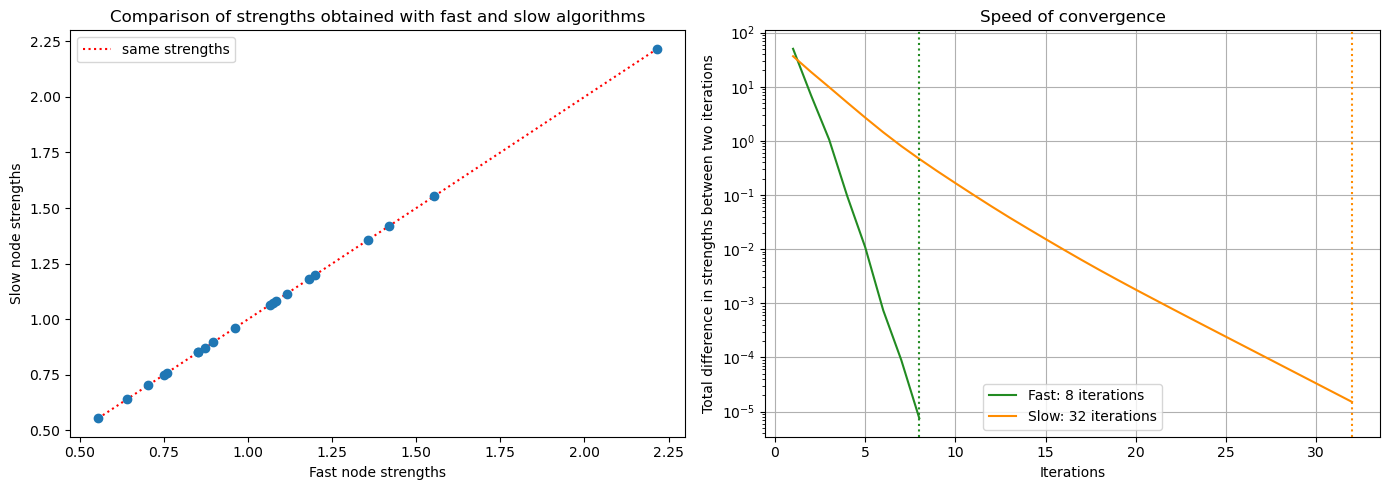

In [159]:
#creation of a random directed network, highly connected
G=nx.gnm_random_graph(20, 200, directed=True)

#calculation of Zermelo's strengths with both algorithms
zermelo_fast, differences_fast,iter_fast = compute_zermelo_strength(G, method="fast", show_convergence=True, keep_differences=True)
zermelo_slow, differences_slow, iter_slow = compute_zermelo_strength(G, method="slow", show_convergence=True, keep_differences=True)

strengths_fast=list(zermelo_fast.values())
strengths_slow=list(zermelo_slow.values())

#find min and max strengths for plotting the diagonal line
minimum_strength=min(min(strengths_fast), min(strengths_slow))
maximum_strength=max(max(strengths_fast), max(strengths_slow))

plt.figure(figsize=(14,5))

#plot of the comparison of the strengths between both algorithms
plt.subplot(1,2,1)
plt.plot([minimum_strength, maximum_strength], [minimum_strength, maximum_strength], color="red", linestyle=":", label="same strengths", zorder=1) #diagonal line
plt.scatter(strengths_fast, strengths_slow, marker="o", zorder=2) 
plt.title("Comparison of strengths obtained with fast and slow algorithms")
plt.xlabel("Fast node strengths")
plt.ylabel("Slow node strengths")
plt.legend()

# plot of the speed of convergence for both algorithms
plt.subplot(1,2,2)
plt.plot(range(1, iter_fast+1), differences_fast, label=f"Fast: {iter_fast} iterations", color="forestgreen")
plt.plot(range(1, iter_slow+1), differences_slow, label=f"Slow: {iter_slow} iterations", color="darkorange")
plt.yscale("log")
plt.axvline(iter_fast, linestyle=":", color="forestgreen")
plt.axvline(iter_slow, linestyle=":", color="darkorange")

plt.title("Speed of convergence")
plt.xlabel("Iterations")
plt.ylabel("Total difference in strengths between two iterations")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [160]:
strengths_differences=[np.abs(strengths_fast[i]-strengths_slow[i]) for i in range(len(strengths_fast))]
mean_difference = np.mean(strengths_differences)
std_difference = np.std(strengths_differences)

print(f"Mean absolute difference for strengths between both algorithms: {mean_difference:.2e} ± {std_difference/np.sqrt(len(strengths_differences)):.2e}")

Mean absolute difference for strengths between both algorithms: 9.12e-07 ± 5.12e-07


We now clearly see that both algorithms converge to the same solution, as the strengths obtained are very similar. The faster algorithm is also more efficient. For these reasons, we will use the fast algorithm for the next steps of the project.

### 2.4. Correlation between the 3 metrics

Before calculating explicitly the correlations between the 3 metrics, we can already have a look at their scatter plots to get an idea of how they relate to each other. To do so, we create a strongly connected random directed network with $N=50$ and $E=1000$, and compute the 3 metrics for each node. The scatter plots are shown below.

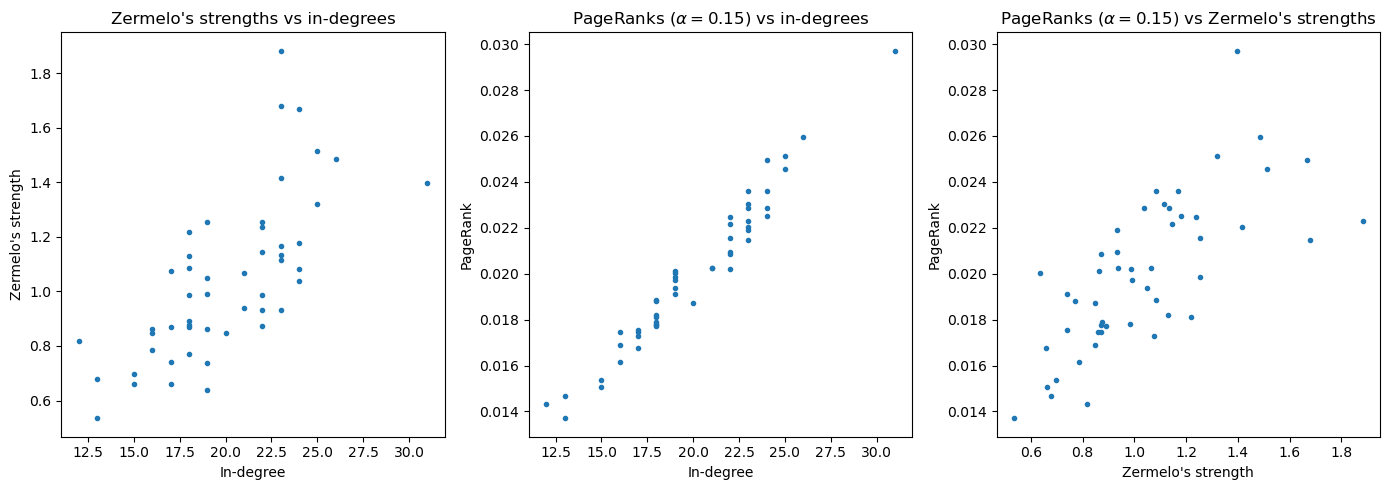

In [161]:
G = nx.gnm_random_graph(50, 1000, directed=True)

#to be sure that the nodes are in the same order for all metrics
nodes = list(G.nodes())

in_degrees = [compute_in_degree(G)[node] for node in nodes]
zermelo_strengths = [compute_zermelo_strength(G, method="fast")[node] for node in nodes]
pageranks = [compute_pagerank(G, alpha=0.15)[node] for node in nodes]


plt.figure(figsize=(14,5))

plt.subplot(1,3,1) 
plt.scatter(in_degrees, zermelo_strengths, marker=".")
plt.title("Zermelo's strengths vs in-degrees")
plt.xlabel("In-degree")
plt.ylabel("Zermelo's strength")

plt.subplot(1,3,2)
plt.scatter(in_degrees, pageranks, marker=".")
plt.title(r"PageRanks ($\alpha=0.15$) vs in-degrees")
plt.xlabel("In-degree")
plt.ylabel("PageRank")

plt.subplot(1,3,3)
plt.scatter(zermelo_strengths, pageranks, marker=".")
plt.title(r"PageRanks ($\alpha=0.15$) vs Zermelo's strengths")
plt.xlabel("Zermelo's strength")
plt.ylabel("PageRank")


plt.tight_layout()
plt.show()

From this result, we can guess that all three metrics are positively correlated, and that the correlation between in-degree and PageRank is the strongest. The two others also seem to be correlated but less. To quantify these observations, we will compute two correlations:
1. **Pearson correlation**: _from the SciPy documentation_, it "measures the linear relationship between two datasets". 

2. **Spearman correlation**: _from the SciPy documentation_, it "is a nonparametric measure of the monotonicity of the relationship between two datasets".

For both of them:

        Like other correlation coefficients, this one varies between -1 and +1 with 0 implying no correlation.   Correlations of -1 or +1 imply an exact linear relationship. Positive correlations imply that as x increases, so does y. Negative correlations imply that as x increases, y decreases.
        
(For more infos, see _References_)

In [162]:
from scipy.stats import pearsonr, spearmanr #libraries for calculating correlations

Here I define 3 functions that will compute the mean Pearson and Spearman correlations between the 3 metrics over a number of random directed graphs with given $N$ and $E$. The first one comparing in-degree and Zermelo returns the mean correlations (with the standard error of the mean) and the two others return dictionaries containing the correlations for different values of $\alpha$.

In [163]:
from tqdm import tqdm

In [164]:
def compare_metrics_random_networks(N, E, graph_number=100, max_iter=500, tol=1.0e-6, alphas=[0.15]):
    """
    Compares in-degree, Zermelo strength, and PageRank correlations on the same set of random graphs

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        graph_number (int): Number of random graphs to generate (default: 100).
        max_iter (int): Maximum number of iterations for Zermelo and PageRank  (default: 5000).
        tol (float): Tolerance for convergence (default: 1.0e-6).


    Returns:
        3 dictionaries for in-degree vs Zermelo, in-degree vs PageRank (for all alphas), Zermelo vs PageRank (for all alphas)
    """

    pearson_in_degree_zermelo_values = []
    spearman_in_degree_zermelo_values = []

    pearson_zermelo_pr_values = {alpha: [] for alpha in alphas}
    spearman_zermelo_pr_values = {alpha: [] for alpha in alphas}

    pearson_in_degree_pr_values = {alpha: [] for alpha in alphas}
    spearman_in_degree_pr_values = {alpha: [] for alpha in alphas}


    
    for _ in tqdm(range(graph_number), desc="Processing graphs"):

        G = nx.gnm_random_graph(N, E, directed=True)
        nodes=list(G.nodes())

        # Compute metrics which don"t depend on alpha
        in_degrees = [compute_in_degree(G)[node] for node in nodes]
        zermelo_strengths = [compute_zermelo_strength(G, method="fast")[node] for node in nodes]

        pearson_indegree_zermelo = pearsonr(in_degrees, zermelo_strengths)[0]
        spearman_indegree_zermelo = spearmanr(in_degrees, zermelo_strengths)[0]

        pearson_in_degree_zermelo_values.append(pearson_indegree_zermelo)
        spearman_in_degree_zermelo_values.append(spearman_indegree_zermelo)

        #compute PageRank
        for alpha in alphas:
            
            pageranks = [compute_pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol)[node] for node in nodes]

            pearson_zermelo_pagerank = pearsonr(zermelo_strengths, pageranks)[0]
            spearman_zermelo_pagerank = spearmanr(zermelo_strengths, pageranks)[0]

            pearson_zermelo_pr_values[alpha].append(pearson_zermelo_pagerank)
            spearman_zermelo_pr_values[alpha].append(spearman_zermelo_pagerank)

            pearson_indegree_pagerank = pearsonr(in_degrees, pageranks)[0]
            spearman_indegree_pagerank = spearmanr(in_degrees, pageranks)[0]

            pearson_in_degree_pr_values[alpha].append(pearson_indegree_pagerank)
            spearman_in_degree_pr_values[alpha].append(spearman_indegree_pagerank)
            
        
    results = {
    "in_degree_zermelo": {
        "pearson": (np.mean(pearson_in_degree_zermelo_values), np.std(pearson_in_degree_zermelo_values)/np.sqrt(graph_number)),
        "spearman": (np.mean(spearman_in_degree_zermelo_values), np.std(spearman_in_degree_zermelo_values)/np.sqrt(graph_number))
    },
    "in_degree_pagerank": {
        alpha: {
            "pearson": (np.mean(pearson_in_degree_pr_values[alpha]), np.std(pearson_in_degree_pr_values[alpha])/np.sqrt(graph_number)),
            "spearman": (np.mean(spearman_in_degree_pr_values[alpha]), np.std(spearman_in_degree_pr_values[alpha])/np.sqrt(graph_number))
                } for alpha in alphas
                            },
    "zermelo_pagerank": {
        alpha: {
            "pearson": (np.mean(pearson_zermelo_pr_values[alpha]), np.std(pearson_zermelo_pr_values[alpha])/np.sqrt(graph_number)),
            "spearman": (np.mean(spearman_zermelo_pr_values[alpha]), np.std(spearman_zermelo_pr_values[alpha])/np.sqrt(graph_number))
                } for alpha in alphas
                        }
    }

    return results

Let's try these functions with $N=50$, $E=1000$ and 200 random graphs, and $\alpha$ ranging from 0 to 1 with a step of 0.05. Note that we can't take $\alpha=1$, as this means that all nodes have the same PageRank score ($=1/N$, uniform distribution), meaning that the correlation is not defined.

In [165]:
alphas = np.concatenate((np.arange(0.05, 1, 0.1), [0.99, 0.999]))
random_networks_metrics=compare_metrics_random_networks(50, 1000, graph_number=200, alphas = alphas)

Processing graphs: 100%|██████████| 200/200 [02:24<00:00,  1.38it/s]


**Results**:

In [166]:
print("Results for correlation between in-degree and Zermelo's strength:")
print("------------------------------------")

print("Pearson:", round(random_networks_metrics["in_degree_zermelo"]["pearson"][0],3), "±", round(random_networks_metrics["in_degree_zermelo"]["pearson"][1],3))
print("Spearman:", round(random_networks_metrics["in_degree_zermelo"]["spearman"][0],3), "±", round(random_networks_metrics["in_degree_zermelo"]["spearman"][1],3))


Results for correlation between in-degree and Zermelo's strength:
------------------------------------
Pearson: 0.669 ± 0.006
Spearman: 0.677 ± 0.006


_Comment_: It shows a medium positive correlation between in-degree and Zermelo's strength, meaning that nodes with a high in-degree tend to have a high Zermelo strength, and that overall ranking is similar. The error are relatively small, so the result is quite conclusive. This theory is confirmed by the scatter plot below, which shows a positive correlation.

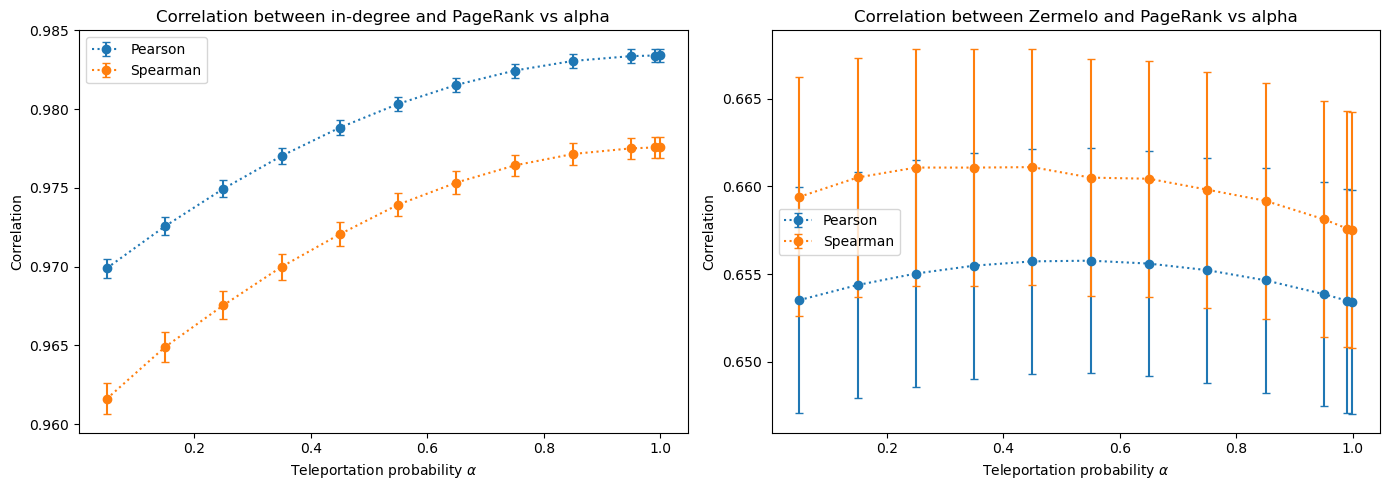

In [167]:
mean_pearson_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["pearson"][0] for alpha in alphas]
se_pearson_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["pearson"][1] for alpha in alphas]
mean_spearman_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["spearman"][0] for alpha in alphas]
se_spearman_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["spearman"][1] for alpha in alphas]

mean_pearson_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["pearson"][0] for alpha in alphas]
se_pearson_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["pearson"][1] for alpha in alphas]
mean_spearman_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["spearman"][0] for alpha in alphas]
se_spearman_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["spearman"][1] for alpha in alphas]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.errorbar(alphas, mean_pearson_ip, yerr=se_pearson_ip, label="Pearson", marker="o", linestyle=":", capsize=3)
plt.errorbar(alphas, mean_spearman_ip, yerr=se_spearman_ip, label="Spearman", marker="o", linestyle=":", capsize=3)
plt.title("Correlation between in-degree and PageRank vs alpha")
plt.xlabel(r"Teleportation probability $\alpha$")
plt.ylabel("Correlation")
plt.legend()

plt.subplot(1,2,2)
plt.errorbar(alphas, mean_pearson_zp, yerr=se_pearson_zp, label="Pearson", marker="o", linestyle=":", capsize=3)
plt.errorbar(alphas, mean_spearman_zp, yerr=se_spearman_zp, label="Spearman", marker="o", linestyle=":", capsize=3)
plt.title("Correlation between Zermelo and PageRank vs alpha")
plt.xlabel(r"Teleportation probability $\alpha$")
plt.ylabel("Correlation")
plt.legend()

plt.tight_layout()
plt.show()

_Comment_: As expected, the correlation between in-degree and PageRank is highly positive (correlations always above 0.93), indicating that high-degree nodes also have a high PageRank (rankings similar). Errors are very small, so the result is conclusive. For the plot on the right, the correlation between Zermelo and PageRank is also positive but lower (about 0.6-0.7) and much more variable with $\alpha$, meaning that Zermelo's strength takes into account different aspects of the network. The errors are quite high here.

#### See evolution of PageRank vs in-degrees with different $\alpha$

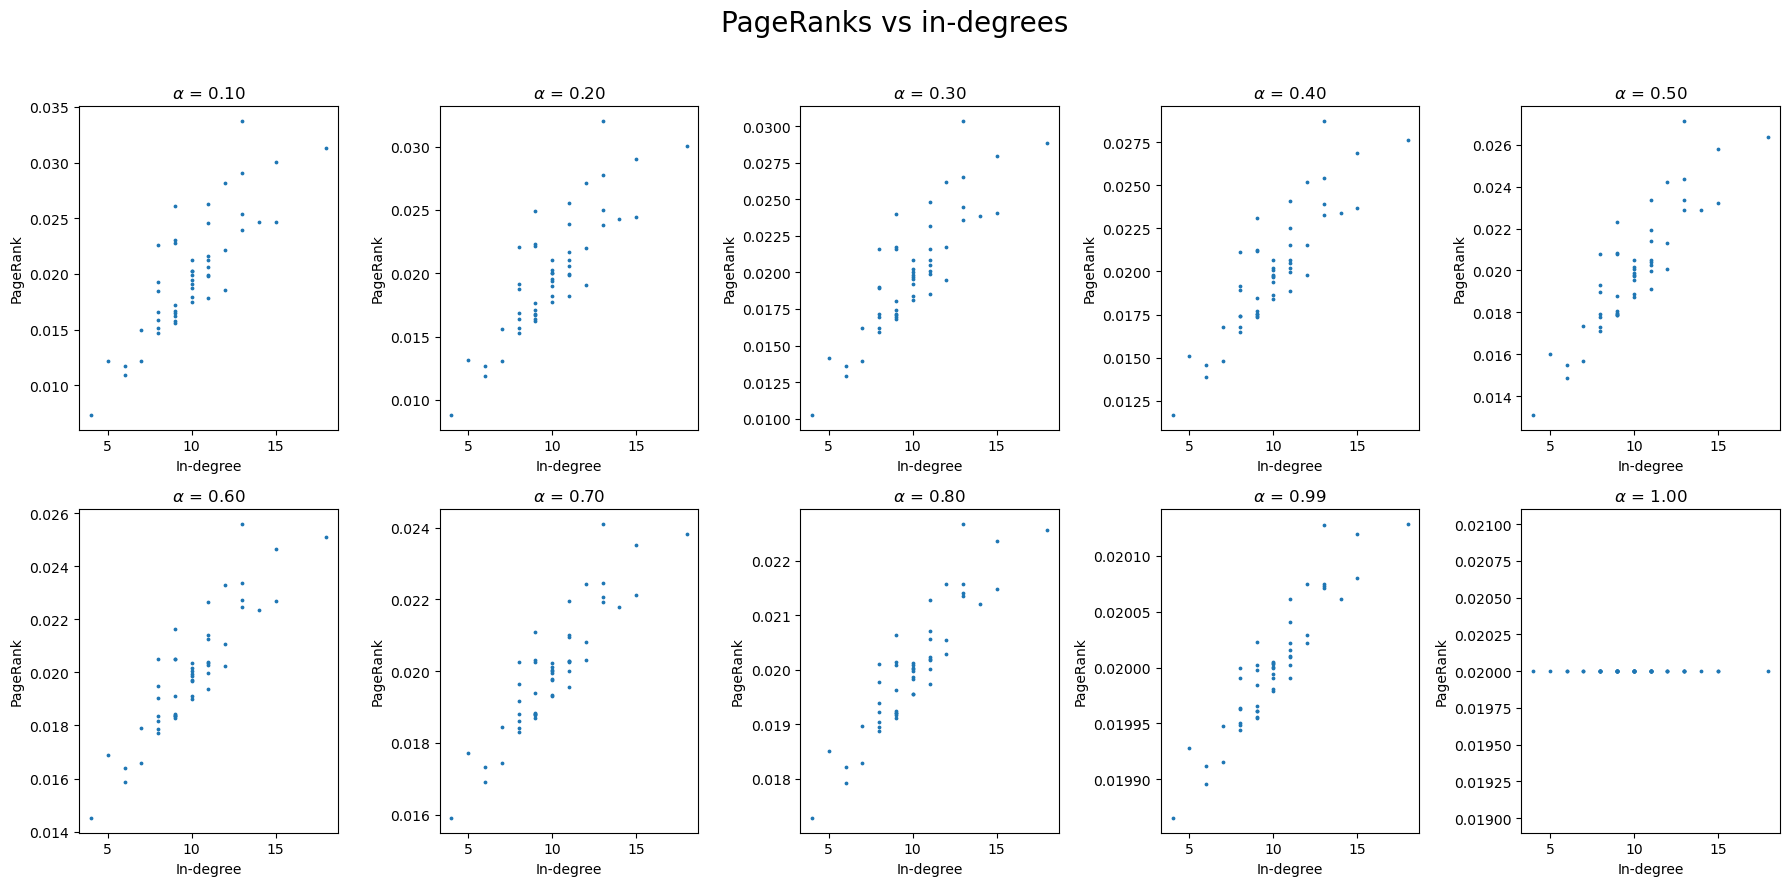

In [168]:
N, E = 50, 500
G = nx.gnm_random_graph(N, E, directed=True)
nodes = list(G.nodes())

alphas = np.concatenate((np.arange(0.1, 0.9, 0.1), [0.99,1]))

in_degrees = [compute_in_degree(G)[node] for node in nodes]


plt.figure(figsize=(18, 9))
for i, alpha in enumerate(alphas):
    pageranks = [compute_pagerank(G, alpha=alpha)[node] for node in nodes]
    
    plt.subplot(2, 5, i+1)
    plt.scatter(in_degrees, pageranks, s=3)
    plt.title(r"$\alpha$ = {:.2f}".format(alpha))
    plt.xlabel("In-degree")
    plt.ylabel("PageRank")

plt.suptitle("PageRanks vs in-degrees", fontsize=20)
             
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Here we see that even for $\alpha=0.99$ (really close to 1), the correlation exists and is still quite strong!

## 3. Simulated outcomes - Bradley-Terry model

The idea in this section is to generate a directed network based on simulated outcomes of pairwise comparisons between players, following the Bradley-Terry model and the probability defined in equation (3). For this, we first assign a true strength $\pi_i$ based on a uniform distribution between 0 and 1. We choose nodes at random and simulate a match where the outcome is determined by the probability $p_{ij}$. As we are using a Digraph, multiple wins of the same player against the same opponent won't be counted more than once. So we may have at the end less than $E$ edges in the network. (Later, we will probably use a weighted directed graph instead, where $w_{ij}$ is the number of wins of player $i$ against player $j$).

Note that we will call this network the Bradley-Terry network, often abbreviated $BT\_network$.

In [169]:
def generate_BT_network(N, E):
    """
    Generates a directed random network with N nodes and E edges, where the links between nodes and their directions are assigned based on Zermelo's model of paired comparisons.
    Note that the number of edges created in the network may be lower than E if some edges are duplicated.

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.

    Returns:
        G (diGraph (from NetworkX)) : A directed graph corresponding to the generated random network.
        true_node_strengths (dict): A dictionary with node indices as keys and their true strengths as values.

        
    """


    #check if the number of edges asked is possible 
    if E>N*(N-1): 
        raise ValueError(f"The maximum number of directed edges with {N} nodes is {N*(N-1)}.")
    
    #creation of the true node strengths
    true_node_strengths = {i: np.random.rand() for i in range(N)}

    #creation of the graph with N nodes
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

 
    for _ in range(E):
        i, j = np.random.choice(range(N), size=2, replace=False)
        p_ij = true_node_strengths[i]/(true_node_strengths[i]+true_node_strengths[j]) 


        if np.random.rand() < p_ij: #creation of a random number btw 0 and 1 to see if i or j wins
            G.add_edge(j,i)
      
        else:
            G.add_edge(i,j)
       
            
    return G, true_node_strengths

#example
# G, true_strengths = generate_BT_network(50,500)
# print(true_strengths)
# print(f"Number of edges (knowing that 500 edges were requested):", len(G.edges()))
# nx.draw_spring(G, with_labels=True)

## 4. Analysis and comparison of the BT networks

### 4.1 . Difference in distribution between the random and the BT network

We first generate a BT network (with simulated true strengths) and a random network with the same number of edges, and we want to compare the distributions for the in-degree, PageRank and Zermelo's node strength. This has been done in 3 steps:

1. **Histograms** are plotted for each metric, and a first comparison was possible.

2. To better see the differences, we use the **Kernel Density Estimation (KDE) plots** to get an estimate of the probability density function of each metric .

3. Finally, **boxplots** are created to have a detailed summary of the distribution of each metric (median, quartiles, ...).

#### Histograms

In [170]:
N=50
E=1000

#creation of the simulated network and calculate the real number of edges 
BT_network, BT_true_strengths=generate_BT_network(N,E)
real_E=len(BT_network.edges())

#creation of a random network with "real_E" edges
random_network=nx.gnm_random_graph(N, real_E, directed=True)

#find nodes
nodes=BT_network.nodes()

#compute in-degrees (list) for each network
in_degrees_BT = [compute_in_degree(BT_network)[node] for node in nodes]
in_degrees_random = [compute_in_degree(random_network)[node] for node in nodes]

#compute Zermelo's strengths for each network
BT_computed_strengths=[compute_zermelo_strength(BT_network)[node] for node in nodes]
random_strengths=[compute_zermelo_strength(random_network)[node] for node in nodes]

# compute pagerank for each network (alpha fixed at 0.15)
pagerank_BT = [compute_pagerank(BT_network, alpha=0.15)[node] for node in nodes] #change alpha!
pagerank_random = [compute_pagerank(random_network, alpha=0.15)[node] for node in nodes]  #change alpha!

#calculations for having the best bins sizes
min_in_degree = min(min(in_degrees_random), min(in_degrees_BT))
max_in_degree = max(max(in_degrees_random), max(in_degrees_BT))
bins_in_degree = range(min_in_degree, max_in_degree + 2, 1)

min_pagerank = min(min(pagerank_random), min(pagerank_BT))
max_pagerank = max(max(pagerank_random), max(pagerank_BT))
bins_pagerank = np.linspace(min_pagerank, max_pagerank, 20)


min_zermelo = min(min(BT_computed_strengths), min(random_strengths))
max_zermelo = max(max(BT_computed_strengths), max(random_strengths))
bins_zermelo = np.linspace(min_zermelo, max_zermelo, 20)

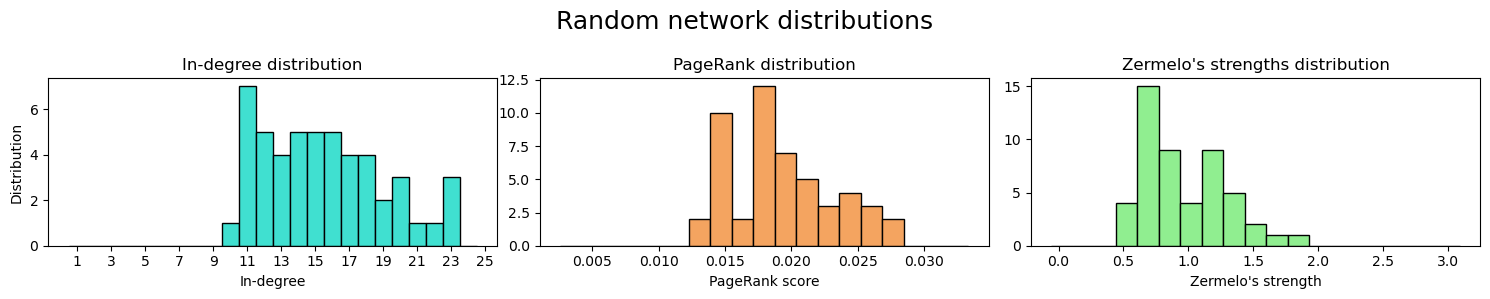

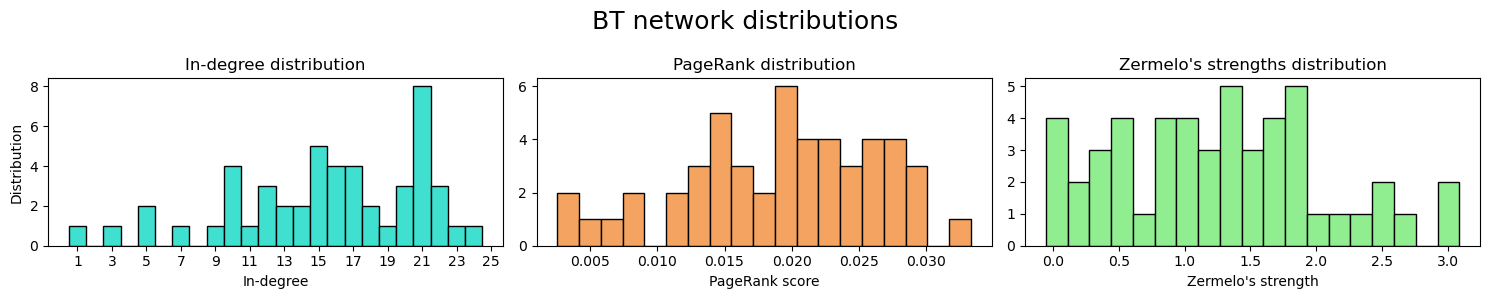

In [171]:
plt.figure(figsize=(15,3))
plt.suptitle("Random network distributions", size=18)


plt.subplot(1,3,1)
plt.hist(in_degrees_random, bins=bins_in_degree, edgecolor="black", color="turquoise", align="left")
plt.xticks(range(min_in_degree, max_in_degree+2, 2))
plt.xlabel("In-degree")
plt.ylabel("Distribution")
plt.title("In-degree distribution")


plt.subplot(1,3,2)
plt.hist(pagerank_random, bins=bins_pagerank ,edgecolor="black", color="sandybrown", align="left")
plt.xlabel("PageRank score")
plt.title("PageRank distribution")



plt.subplot(1,3,3)
plt.hist(random_strengths, bins=bins_zermelo, edgecolor="black", color="lightgreen", align="left")
plt.xlabel("Zermelo's strength")
plt.title("Zermelo's strengths distribution")

plt.tight_layout()
plt.show()

#-------------------------

plt.figure(figsize=(15,3))
plt.suptitle("BT network distributions", size=18)


plt.subplot(1,3,1)
plt.hist(in_degrees_BT, bins=bins_in_degree, edgecolor="black", color="turquoise", align="left")
plt.xticks(range(min_in_degree, max_in_degree+2, 2))
plt.xlabel("In-degree")
plt.ylabel("Distribution")
plt.title("In-degree distribution")


plt.subplot(1,3,2)
plt.hist(pagerank_BT, bins=bins_pagerank ,edgecolor="black", color="sandybrown", align="left")
plt.xlabel("PageRank score")
plt.title("PageRank distribution")



plt.subplot(1,3,3)
plt.hist(BT_computed_strengths, bins=bins_zermelo, edgecolor="black", color="lightgreen", align="left")
plt.xlabel("Zermelo's strength")
plt.title("Zermelo's strengths distribution")

plt.tight_layout()
plt.show()


_Comment:_ Here we get an overview of the distributions. They are less symmetric and more dispersed in the BT network than in the random one. Some nodes have much lower/higher degrees and have very high strengths for example. 

#### KDE plots

In [172]:
import seaborn as sns # to use the built-in function "sns.kdeplot"

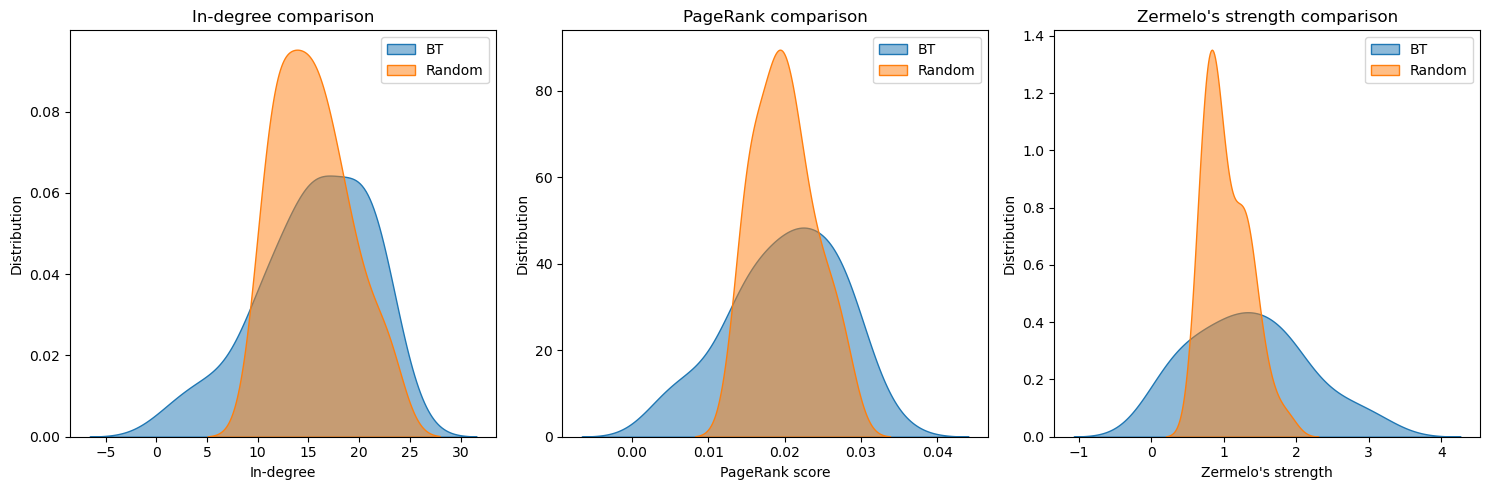

In [173]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.kdeplot(in_degrees_BT, label="BT", fill=True, alpha=0.5)
sns.kdeplot(in_degrees_random, label="Random", fill=True, alpha=0.5)
plt.xlabel("In-degree")
plt.ylabel("Distribution")
plt.legend()
plt.title("In-degree comparison")

plt.subplot(1,3,2)
sns.kdeplot(pagerank_BT, label="BT", fill=True, alpha=0.5)
sns.kdeplot(pagerank_random, label="Random", fill=True, alpha=0.5)
plt.xlabel("PageRank score")
plt.ylabel("Distribution")
plt.legend()
plt.title("PageRank comparison")

plt.subplot(1,3,3)
sns.kdeplot(BT_computed_strengths, label="BT", fill=True, alpha=0.5)
sns.kdeplot(random_strengths, label="Random", fill=True, alpha=0.5)
plt.xlabel("Zermelo's strength")
plt.ylabel("Distribution")
plt.legend()
plt.title("Zermelo's strength comparison")

plt.tight_layout()
plt.show()

_Comment:_ These KDE plots give us a better visualisation of the differences between the BT and random networks. Overall, the random network shows peaked and narrow distributions for all 3 metrics. For the BT one, it is broader and this confirms that node values are more dispersed.


#### Boxplot

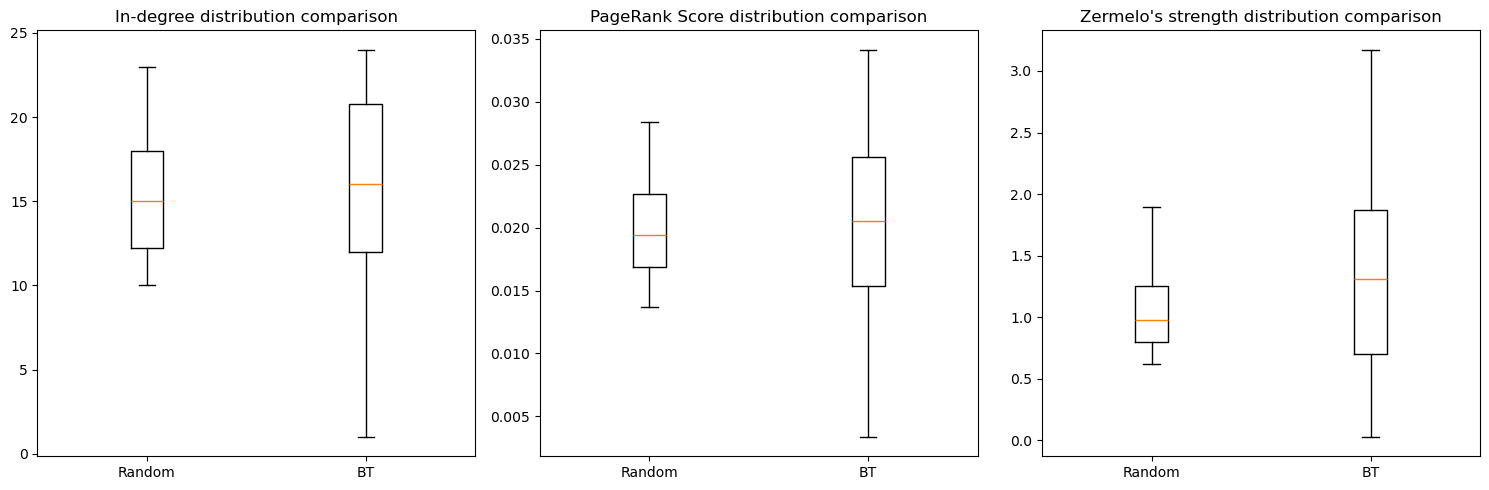

In [174]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.boxplot([in_degrees_random, in_degrees_BT], tick_labels=["Random", "BT"])
plt.title("In-degree distribution comparison")

plt.subplot(1,3,2)
plt.boxplot([pagerank_random, pagerank_BT], tick_labels=["Random", "BT"])
plt.title("PageRank Score distribution comparison")

plt.subplot(1,3,3)
plt.boxplot([random_strengths, BT_computed_strengths], tick_labels=["Random", "BT"])
plt.title("Zermelo's strength distribution comparison")

plt.tight_layout()
plt.show()

_Comment:_ The median values of the BT network are close with those of the random one. This shows us that the simulated outcomes do not shift the average value. However, there is a big difference in the Interquartile Range (IQR, corresponding to the middle 50% of a dataset): it is much wider in the BT network, for all metrics. 

### 4.2. Correlation between true node strength and in-degree/computed node strength

As before, I define a function to compute the mean Pearson and Spearman correlations between the true node strength and in-degree/computed node strength (over a number of graphs with given $N$ and $E$), and PR (with different alphas). In this case, the network $G$ generated can be chosen between "BT" (with the function defined earlier) or "biased" (see section 5). 

In [175]:
def compare_metrics_with_true_strengths(N, E, network_type, graph_number=100, max_iter=500, tol=1.0e-6, alphas=[0.15], return_real_E=False):

    """
    Compares true node strengths against in-degree, Zermelo strength, and PageRank 
    by calculating correlations on the same set of random graphs (BT or Biased).

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        network_type (str): Type of network generated (can be "BT" or "biased")
        graph_number (int): Number of random graphs to generate (default: 100).
        max_iter (int): Maximum number of iterations for Zermelo and PageRank (default: 500).
        tol (float): Tolerance for convergence (default: 1.0e-6).
        alphas (list): List of alpha values for PageRank (default: [0.15]).
        return_real_E: if True, returns the real number of edges in the network for each graph created (default: False)

    Returns:
        3 dictionaries for true_strengths vs in-degree, true_strengths vs Zermelo, 
        and true_strengths vs PageRank (for all alphas), containing mean and standard error 
        of Pearson's and Spearman's correlation coefficients.
    """
    if (network_type != "BT") and (network_type != "biased"):
        raise ValueError("The network type has to be either 'BT' or 'biased'.")

    #initialization for stocking the results
    pearson_true_indegree_values = []
    spearman_true_indegree_values = []
    
    pearson_true_zermelo_values = []
    spearman_true_zermelo_values = []

    pearson_true_pr_values = {alpha: [] for alpha in alphas}
    spearman_true_pr_values = {alpha: [] for alpha in alphas}

    E_real_list = []
    density_real_list = []

    for _ in tqdm(range(graph_number), desc=f"Processing {network_type} graphs"):

        if network_type == "BT":
            G, true_strengths = generate_BT_network(N, E) 
        else:
            G, true_strengths = generate_biased_network(N, E)

        nodes=list(G.nodes())

        #changing dictionary into list
        true_strengths=[true_strengths[node] for node in nodes]

        # computing in-degree and zermelo's strengths
        in_degrees = [compute_in_degree(G)[node] for node in nodes]

        try: # computing zermelo's strengths and see if we have a solution or not (if no, we skip the graph)
            zermelo_strengths = [compute_zermelo_strength(G, method="fast", max_iter=max_iter)[node] for node in nodes]
        except ValueError:
            continue

        #compute Pearson and Spearman correlations
        pearson_true_indegree = pearsonr(true_strengths, in_degrees)[0]
        spearman_true_indegree = spearmanr(true_strengths, in_degrees)[0]
        pearson_true_zermelo = pearsonr(true_strengths, zermelo_strengths)[0]
        spearman_true_zermelo = spearmanr(true_strengths, zermelo_strengths)[0]
        
        pearson_true_indegree_values.append(pearson_true_indegree)
        spearman_true_indegree_values.append(spearman_true_indegree)
        pearson_true_zermelo_values.append(pearson_true_zermelo)
        spearman_true_zermelo_values.append(spearman_true_zermelo)

        #calcuation of correlations for PR as a function of alpha
        for alpha in alphas:
            
            pageranks = [compute_pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol)[node] for node in nodes]

            pearson_true_pagerank = pearsonr(true_strengths, pageranks)[0]
            spearman_true_pagerank = spearmanr(true_strengths, pageranks)[0]

            pearson_true_pr_values[alpha].append(pearson_true_pagerank)
            spearman_true_pr_values[alpha].append(spearman_true_pagerank)


        if return_real_E:
            E_real_list.append(len(G.edges()))
            density_real_list.append(len(G.edges()) / (N*(N-1)))


    real_graph_number = len(pearson_true_indegree_values)

    results = {
    "in_degree": {
        "pearson": (np.mean(pearson_true_indegree_values), np.std(pearson_true_indegree_values)/np.sqrt(real_graph_number)),
        "spearman": (np.mean(spearman_true_indegree_values), np.std(spearman_true_indegree_values)/np.sqrt(real_graph_number))
    },
    "pagerank": {
        alpha: {
            "pearson": (np.mean(pearson_true_pr_values[alpha]), np.std(pearson_true_pr_values[alpha])/np.sqrt(real_graph_number)),
            "spearman": (np.mean(spearman_true_pr_values[alpha]), np.std(spearman_true_pr_values[alpha])/np.sqrt(real_graph_number))
                } for alpha in alphas
                            },
    "zermelo": {
       
            "pearson": (np.mean(pearson_true_zermelo_values), np.std(pearson_true_zermelo_values)/np.sqrt(real_graph_number)),
            "spearman": (np.mean(spearman_true_zermelo_values), np.std(spearman_true_zermelo_values)/np.sqrt(real_graph_number))
                }           
    }

    if return_real_E:
        results["E_real_mean"] = np.mean(E_real_list)
        results["density_real_mean"] = np.mean(density_real_list)
    
    return results

In [176]:
#use the function defined above
alphas = np.concatenate((np.arange(0.05, 1, 0.1), [0.99, 0.999]))
BT_correlations = compare_metrics_with_true_strengths(50, 1000, graph_number=200, network_type="BT", alphas=alphas)

Processing BT graphs: 100%|██████████| 200/200 [02:25<00:00,  1.38it/s]


In [177]:
BT_pagerank_correlations=BT_correlations["pagerank"]
BT_zermelo_correlations=BT_correlations["zermelo"]
BT_in_degree_correlations=BT_correlations["in_degree"]

**Results**

In [178]:

print("Results for correlation between in-degree and true node strength:")
print("------------------------------------")

print("Pearson:", round(BT_in_degree_correlations["pearson"][0],3), "±", round(BT_in_degree_correlations["pearson"][1],3))
print("Spearman:", round(BT_in_degree_correlations["spearman"][0],3), "±", round(BT_in_degree_correlations["spearman"][1],3))


print("\nResults for correlation between computed and true node strength:")
print("------------------------------------")

print("Pearson:", round(BT_zermelo_correlations["pearson"][0],3), "±", round(BT_zermelo_correlations["pearson"][1],3))
print("Spearman:", round(BT_zermelo_correlations["spearman"][0],3), "±", round(BT_zermelo_correlations["spearman"][1],3))

Results for correlation between in-degree and true node strength:
------------------------------------
Pearson: 0.784 ± 0.004
Spearman: 0.769 ± 0.005

Results for correlation between computed and true node strength:
------------------------------------
Pearson: 0.801 ± 0.004
Spearman: 0.853 ± 0.003


_Comment_: All correlations are positive and greater than 0.7, indicating that there is a strong relations between the metrics. The computed strength metric shows a higher Spearman correlation compared to the in-degree one. It shows that the computed strength is a better predictor of the rank order of the true node strength. 

### 4.3. Influence of the $\alpha$-parameter

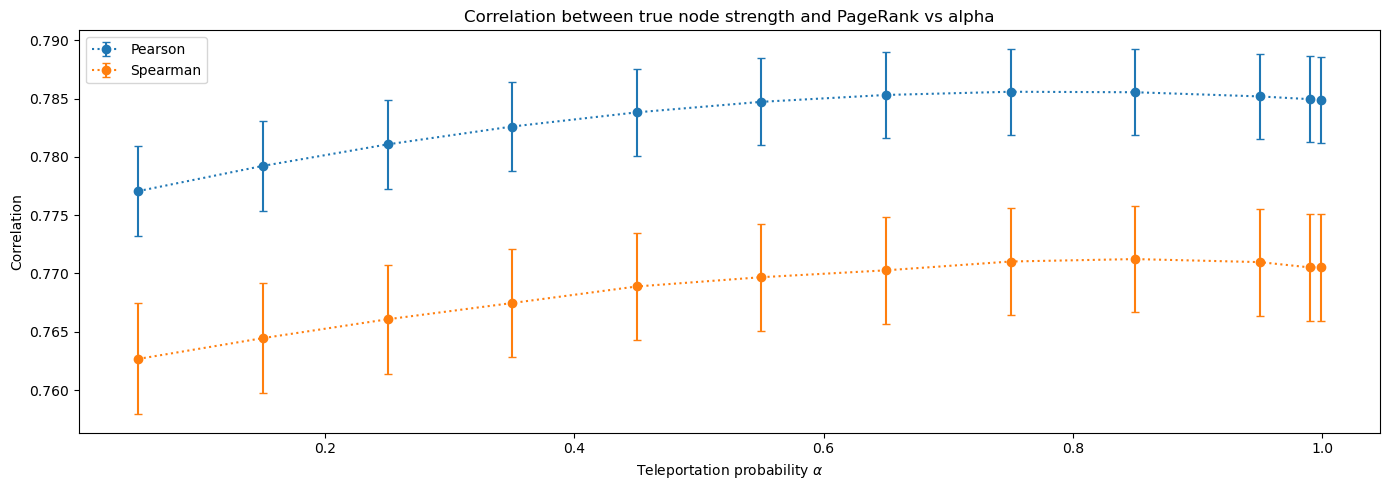

In [179]:
#plot of the results
plt.figure(figsize=(14,5))

plt.errorbar(alphas, [BT_pagerank_correlations[alpha]["pearson"][0] for alpha in map(float, alphas)], yerr=[BT_pagerank_correlations[alpha]["pearson"][1] for alpha in map(float, alphas)], label="Pearson", marker="o", linestyle=":", capsize=3)
plt.errorbar(alphas, [BT_pagerank_correlations[alpha]["spearman"][0] for alpha in map(float, alphas)], yerr=[BT_pagerank_correlations[alpha]["spearman"][1] for alpha in map(float, alphas)], label="Spearman", marker="o", linestyle=":", capsize=3)
plt.title("Correlation between true node strength and PageRank vs alpha")
plt.xlabel(r"Teleportation probability $\alpha$")
plt.ylabel("Correlation")
plt.legend()

plt.tight_layout()
plt.show()

_Comment_: This plot shows that both correlations are quite high, with the Pearson correlation being slightly higher. The values are all contained in a narrow range, and $\alpha$ doesn't seem to have much influence on the results.

**Comparison of all correlations calculated**

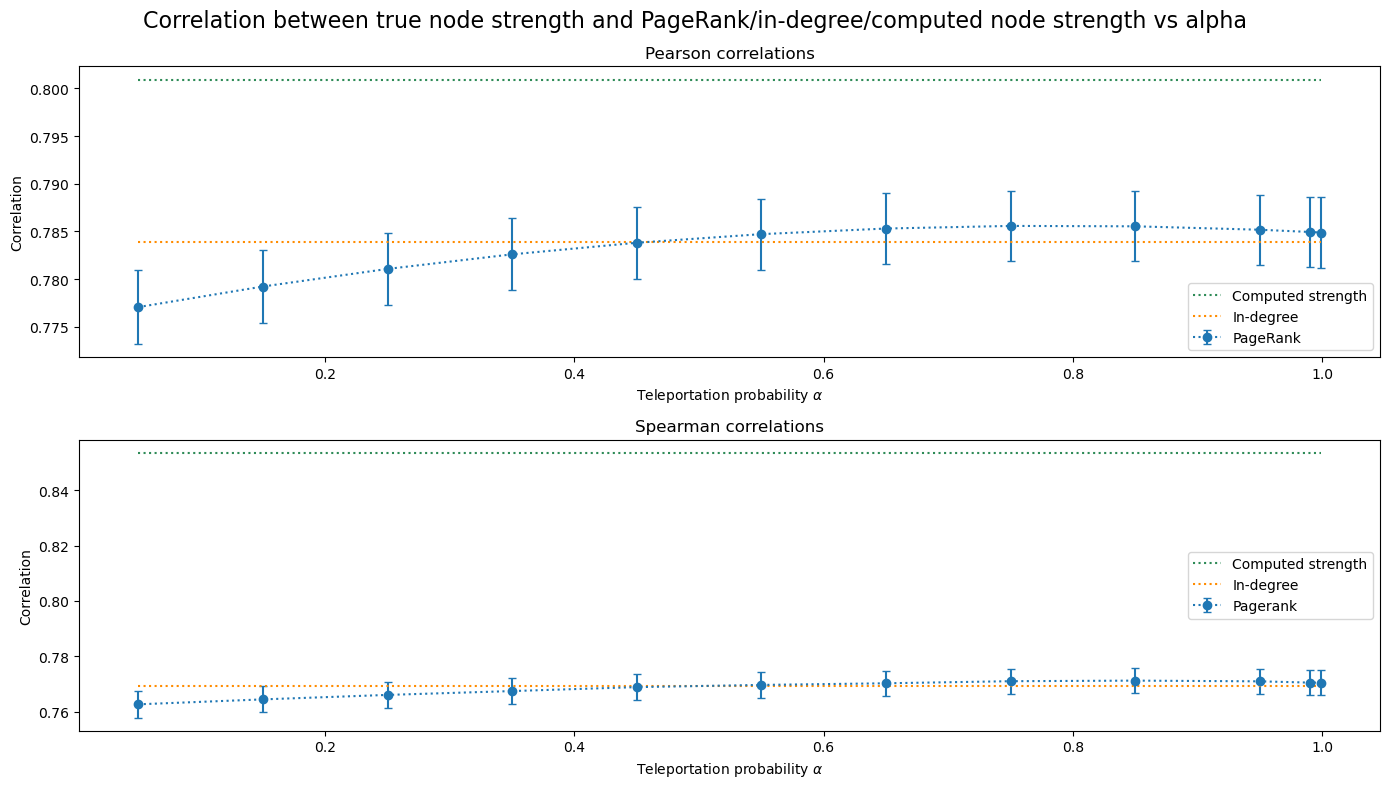

In [180]:
plt.figure(figsize=(14,8))

plt.subplot(2,1,1)

plt.title("Pearson correlations")
plt.errorbar(alphas, [BT_pagerank_correlations[alpha]["pearson"][0] for alpha in alphas], yerr=[BT_pagerank_correlations[alpha]["pearson"][1] for alpha in alphas], label="PageRank", marker="o", linestyle=":", capsize=3)
plt.plot(alphas, [BT_zermelo_correlations["pearson"][0]]*len(alphas),label="Computed strength",marker="", linestyle=":",color="seagreen")
plt.plot(alphas, [BT_in_degree_correlations["pearson"][0]]*len(alphas),label="In-degree",marker="", linestyle=":",color="darkorange")
plt.xlabel(r"Teleportation probability $\alpha$")
plt.ylabel("Correlation")
plt.legend()

plt.subplot(2,1,2)
plt.title("Spearman correlations")
plt.errorbar(alphas, [BT_pagerank_correlations[alpha]["spearman"][0] for alpha in alphas], yerr=[BT_pagerank_correlations[alpha]["spearman"][1] for alpha in alphas], label="Pagerank", marker="o", linestyle=":", capsize=3)
plt.plot(alphas, [BT_zermelo_correlations["spearman"][0]]*len(alphas),label="Computed strength",marker="", linestyle=":",color="seagreen")
plt.plot(alphas, [BT_in_degree_correlations["spearman"][0]]*len(alphas),label="In-degree",marker="", linestyle=":",color="darkorange")



plt.suptitle("Correlation between true node strength and PageRank/in-degree/computed node strength vs alpha", fontsize=16)
plt.xlabel(r"Teleportation probability $\alpha$")
plt.ylabel("Correlation")
plt.legend()

plt.tight_layout()
plt.show()

This last result for the simulated network compares all correlations and shows that the computed node strength correlates best with the true node strength. One reason could be that it is designed to estimate the true node strength (and it takes into account the simulated outcomes as well as the strength of the neighbors). In contrast, in-degree only counts the number of incoming links without considering whether they come from strong or weak nodes. In a similar way, PageRank gives values reflecting the importance of a node whithin the network structure rather than "strengths". 

One other observation is that the $\alpha$-parameter has little impact on the correlation, and no values permit to have higher correlation than the computed strengths.

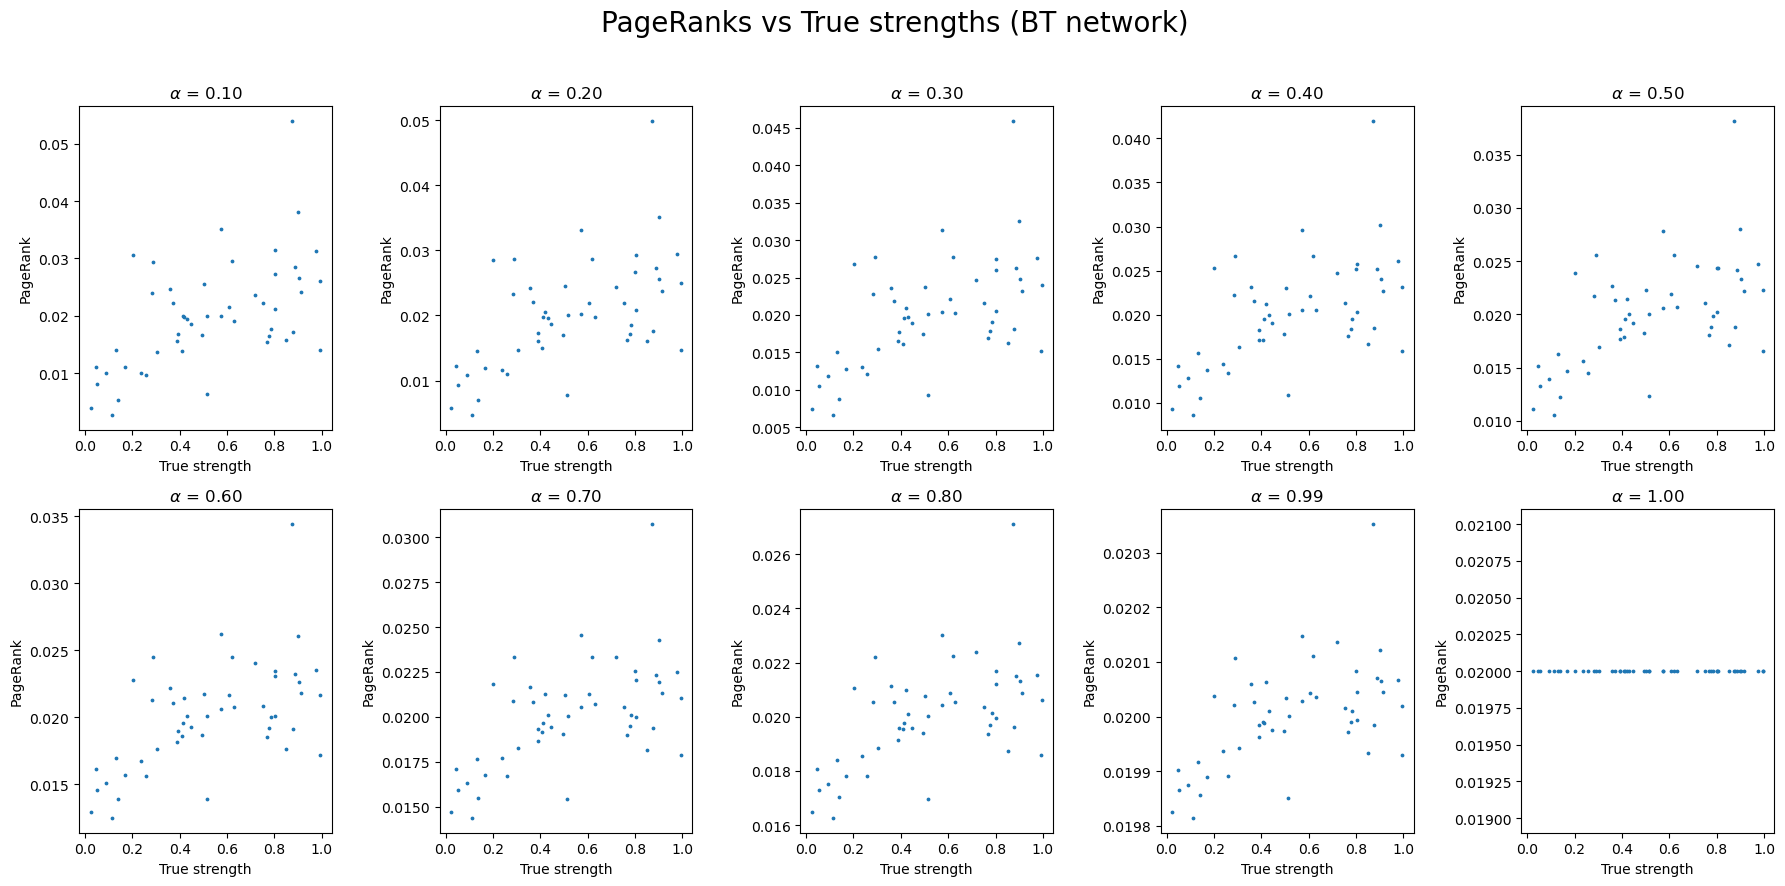

In [181]:
N, E = 50, 500
G, true_strengths = generate_BT_network(N,E)
nodes = list(G.nodes())

alphas = np.concatenate((np.arange(0.1, 0.9, 0.1), [0.99,1]))


plt.figure(figsize=(18, 9))
for i, alpha in enumerate(alphas):
    pageranks = [compute_pagerank(G, alpha=alpha)[node] for node in nodes]
    
    plt.subplot(2, 5, i+1)
    true_strengths_list = [true_strengths[node] for node in nodes]
    plt.scatter(true_strengths_list, pageranks, s=3)
    plt.title(r"$\alpha$ = {:.2f}".format(alpha))
    plt.xlabel("True strength")
    plt.ylabel("PageRank")

plt.suptitle("PageRanks vs True strengths (BT network)", fontsize=20)
             
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 5. Further variation - Biased sampling

The last part of this notebook consists of generating another type of network: the "biased" networks. They are constructed as the simulated network, but the difference is that the pairs of nodes are not chosen randomly, but according to a certain probability. 

In networks, nodes are labelled from $0$ to $N-1$, so the probability of selecting a node $i$ is initally $1/\sqrt{i+1}$ (shift for avoiding division by 0). To ensure that the sum of probabilities is 1, we have to normalize  each terme by the total sum over all nodes:

$\begin{equation} P(i)=\frac{1/\sqrt{i+1}}{\sum_{j=0}^{N-1} 1/\sqrt{j+1}} \end{equation}$

In [182]:
def generate_biased_network(N,E):
    """
    Generates a directed random network with N nodes and E edges, where pair of nodes are selected at random, where lower IDs are more likely to be selected. 
    The directions of the edges are determined using Zermelo's model and probability.
    Note that the number of edges created in the network may be lower than E if some edges are duplicated.

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.

    Returns:
        G (diGraph (from NetworkX)) : A directed graph corresponding to the generated random network.
        true_node_strengths (dict): A dictionary with node indices as keys and their true strengths as values.

    """

    #check if the number of edges asked is possible 
    if E>N*(N-1): 
        raise ValueError(f"The maximum number of directed edges with {N} nodes is {N*(N-1)}.")
    

    #creation of the true node strengths
    true_node_strengths = {i: np.random.rand() for i in range(N)}

    #creation of the graph with N nodes
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    # create a list containing probabilities for a node to be chosen: 1/sqrt(i+1)/sum of probabilities
    probabilities = [(1/np.sqrt(i+1))/np.sum([1/np.sqrt(j+1) for j in range(N)]) for i in range(N)]

    #choosing pair of nodes according to the probabilities
    for _ in range(E):
        i, j = np.random.choice(range(N), size=2, replace=False, p=probabilities)
        p_ij = true_node_strengths[i]/(true_node_strengths[i]+true_node_strengths[j]) 


        if np.random.rand() < p_ij: #creation of a random number btw 0 and 1 to see if i or j wins
            G.add_edge(j,i)
      
        else:
            G.add_edge(i,j)
       
            
    return G, true_node_strengths
    

# example
# G, true_strengths = generate_biased_network(50,1000)
# print(true_strengths)
# print(f"Number of edges (knowing that 1000 edges were requested):", len(G.edges()))
# nx.draw_spring(G, with_labels=True)

#### See the distribution of a biased network

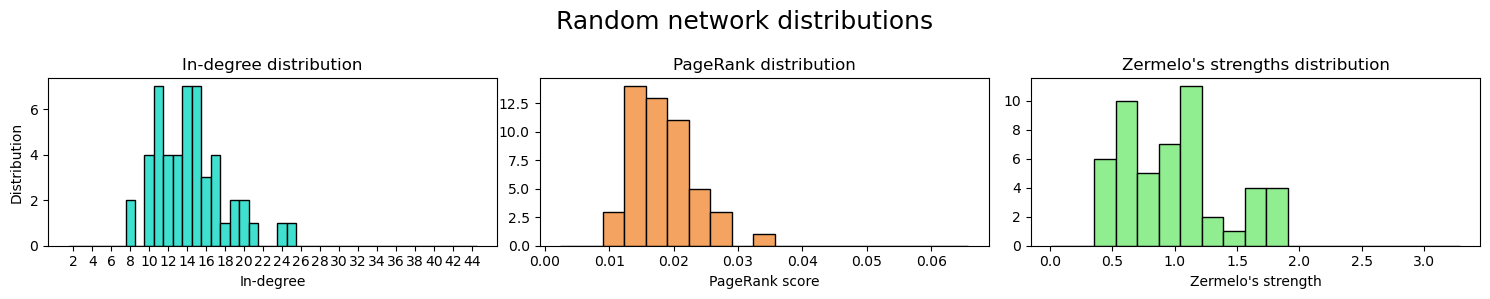

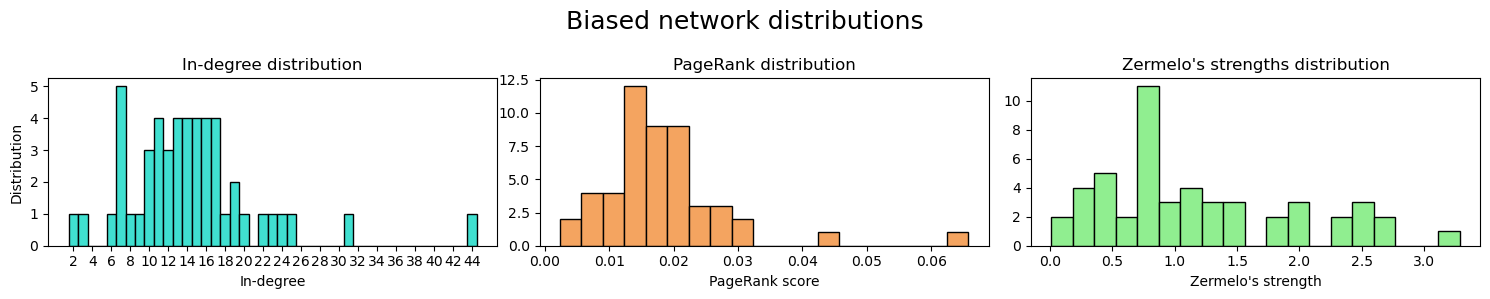

In [183]:
N=50
E=1000


#creation of a biased network
biased_network, biased_true_strengths=generate_biased_network(N,E)
real_E=len(biased_network.edges())

#creation of a random network with "real_E" edges
random_network=nx.gnm_random_graph(N, real_E, directed=True)

#find nodes
nodes=biased_network.nodes()

#compute in-degrees (list) for each network
in_degrees_random = [compute_in_degree(random_network)[node] for node in nodes]
in_degrees_biased = [compute_in_degree(biased_network)[node] for node in nodes]

#compute Zermelo's strengths for each network
random_strengths=[compute_zermelo_strength(random_network)[node] for node in nodes]


biased_computed_strengths=[compute_zermelo_strength(biased_network)[node] for node in nodes]


# compute pagerank for each network (alpha fixed at 0.15)
pagerank_random = [compute_pagerank(random_network, alpha=0.15)[node] for node in nodes] 
pagerank_biased = [compute_pagerank(biased_network, alpha=0.15)[node] for node in nodes]  

#calculations for having the best bins sizes
min_in_degree = min(min(in_degrees_random), min(in_degrees_biased))
max_in_degree = max(max(in_degrees_random), max(in_degrees_biased))
bins_in_degree = range(min_in_degree, max_in_degree + 2, 1)

min_pagerank = min(min(pagerank_random), min(pagerank_biased))
max_pagerank = max(max(pagerank_random), max(pagerank_biased))
bins_pagerank = np.linspace(min_pagerank, max_pagerank, 20)


min_zermelo = min(min(random_strengths), min(biased_computed_strengths))
max_zermelo = max(max(random_strengths), max(biased_computed_strengths))
bins_zermelo = np.linspace(min_zermelo, max_zermelo, 20)

plt.figure(figsize=(15,3))
plt.suptitle("Random network distributions", size=18)


plt.subplot(1,3,1)
plt.hist(in_degrees_random, bins=bins_in_degree, edgecolor="black", color="turquoise", align="left")
plt.xticks(range(min_in_degree, max_in_degree+2, 2))
plt.xlabel("In-degree")
plt.ylabel("Distribution")
plt.title("In-degree distribution")


plt.subplot(1,3,2)
plt.hist(pagerank_random, bins=bins_pagerank ,edgecolor="black", color="sandybrown", align="left")
plt.xlabel("PageRank score")
plt.title("PageRank distribution")



plt.subplot(1,3,3)
plt.hist(random_strengths, bins=bins_zermelo, edgecolor="black", color="lightgreen", align="left")
plt.xlabel("Zermelo's strength")
plt.title("Zermelo's strengths distribution")

plt.tight_layout()
plt.show()

#------------------------------

plt.figure(figsize=(15,3))
plt.suptitle("Biased network distributions", size=18)


plt.subplot(1,3,1)
plt.hist(in_degrees_biased, bins=bins_in_degree, edgecolor="black", color="turquoise", align="left")
plt.xticks(range(min_in_degree, max_in_degree+2, 2))
plt.xlabel("In-degree")
plt.ylabel("Distribution")
plt.title("In-degree distribution")


plt.subplot(1,3,2)
plt.hist(pagerank_biased, bins=bins_pagerank ,edgecolor="black", color="sandybrown", align="left")
plt.xlabel("PageRank score")
plt.title("PageRank distribution")



plt.subplot(1,3,3)
plt.hist(biased_computed_strengths, bins=bins_zermelo, edgecolor="black", color="lightgreen", align="left")
plt.xlabel("Zermelo's strength")
plt.title("Zermelo's strengths distribution")

plt.tight_layout()
plt.show()


In [184]:
#use the function defined above
alphas = np.concatenate((np.arange(0.05, 1, 0.1), [0.99, 0.999]))
biased_correlations = compare_metrics_with_true_strengths(50, 1000, graph_number=200, network_type="biased", alphas=alphas)

Processing biased graphs: 100%|██████████| 200/200 [02:21<00:00,  1.42it/s]


In [185]:
biased_pagerank_correlations=biased_correlations["pagerank"]
biased_zermelo_correlations=biased_correlations["zermelo"]
biased_in_degree_correlations=biased_correlations["in_degree"]

**Results**

In [186]:
print("Results for correlation between in-degree and true node strength (biased network):")
print("------------------------------------")

print("Pearson:", round(biased_in_degree_correlations["pearson"][0],3), "±", round(biased_in_degree_correlations["pearson"][1],3))
print("Spearman:", round(biased_in_degree_correlations["spearman"][0],3), "±", round(biased_in_degree_correlations["spearman"][1],3))


print("\nResults for correlation between computed and true node strength (biased network):")
print("------------------------------------")

print("Pearson:", round(biased_zermelo_correlations["pearson"][0],3), "±", round(biased_zermelo_correlations["pearson"][1],3))
print("Spearman:", round(biased_zermelo_correlations["spearman"][0],3), "±", round(biased_zermelo_correlations["spearman"][1],3))

Results for correlation between in-degree and true node strength (biased network):
------------------------------------
Pearson: 0.535 ± 0.006
Spearman: 0.58 ± 0.007

Results for correlation between computed and true node strength (biased network):
------------------------------------
Pearson: 0.742 ± 0.005
Spearman: 0.831 ± 0.004


_Comment_: In the biased network, the correlation between in-degree and true node strength is much lower than in the simulated network. The computed strength metric shows higher values as before, but a little bit lower. We can conclude that for both simulated and biased networks, the computed strength is the best in terms of correlation.

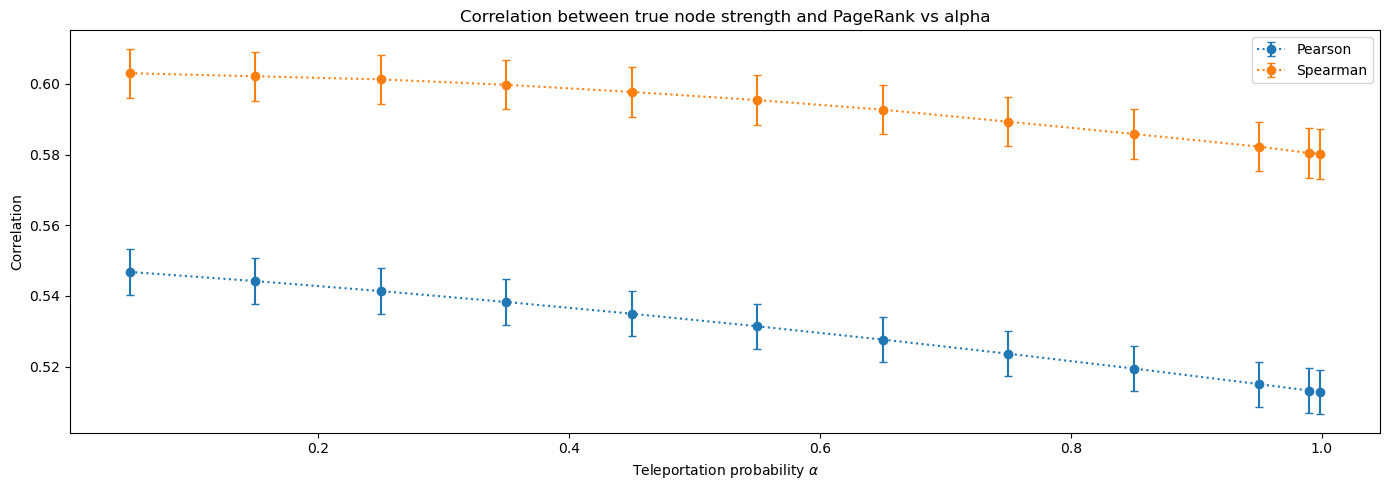

In [187]:
#plot of the results
plt.figure(figsize=(14,5))

plt.errorbar(alphas, [biased_pagerank_correlations[alpha]["pearson"][0] for alpha in map(float, alphas)], yerr=[biased_pagerank_correlations[alpha]["pearson"][1] for alpha in map(float, alphas)], label="Pearson", marker="o", linestyle=":", capsize=3)
plt.errorbar(alphas, [biased_pagerank_correlations[alpha]["spearman"][0] for alpha in map(float, alphas)], yerr=[biased_pagerank_correlations[alpha]["spearman"][1] for alpha in map(float, alphas)], label="Spearman", marker="o", linestyle=":", capsize=3)
plt.title("Correlation between true node strength and PageRank vs alpha")
plt.xlabel(r"Teleportation probability $\alpha$")
plt.ylabel("Correlation")
plt.legend()

plt.tight_layout()
plt.show()

From this graph, we see that the correlation has decreased compared to the simulated network. We also see that $\alpha$ has no real influence on the correlations.

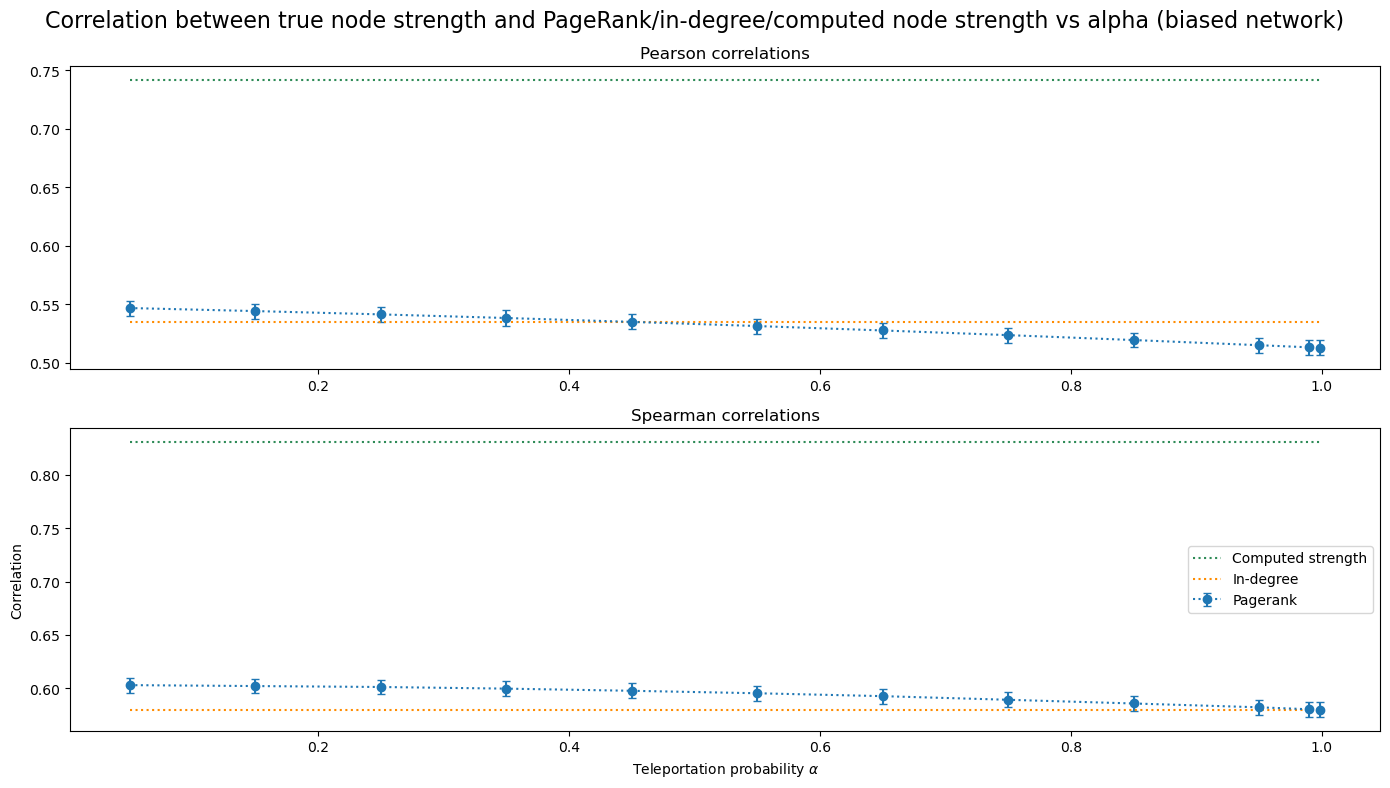

In [188]:
plt.figure(figsize=(14,8))

plt.subplot(2,1,1)

plt.title("Pearson correlations")
plt.errorbar(alphas, [biased_pagerank_correlations[alpha]["pearson"][0] for alpha in alphas], yerr=[biased_pagerank_correlations[alpha]["pearson"][1] for alpha in alphas], label="PageRank", marker="o", linestyle=":", capsize=3)
plt.plot(alphas, [biased_zermelo_correlations["pearson"][0]]*len(alphas),label="Computed strength",marker="", linestyle=":",color="seagreen")
plt.plot(alphas, [biased_in_degree_correlations["pearson"][0]]*len(alphas),label="In-degree",marker="", linestyle=":",color="darkorange")


plt.subplot(2,1,2)
plt.title("Spearman correlations")
plt.errorbar(alphas, [biased_pagerank_correlations[alpha]["spearman"][0] for alpha in alphas], yerr=[biased_pagerank_correlations[alpha]["spearman"][1] for alpha in alphas], label="Pagerank", marker="o", linestyle=":", capsize=3)
plt.plot(alphas, [biased_zermelo_correlations["spearman"][0]]*len(alphas),label="Computed strength",marker="", linestyle=":",color="seagreen")
plt.plot(alphas, [biased_in_degree_correlations["spearman"][0]]*len(alphas),label="In-degree",marker="", linestyle=":",color="darkorange")



plt.suptitle("Correlation between true node strength and PageRank/in-degree/computed node strength vs alpha (biased network)", fontsize=16)
plt.xlabel(r"Teleportation probability $\alpha$")
plt.ylabel("Correlation")
plt.legend()

plt.tight_layout()
plt.show()

This confirms us again that the computed strength has the best correlation with the true node strength.

## 6. Study of the influence of parameters $N$ and $E$ on correlations

Here I want to study the influence of the number of nodes $N$ and edges $E$ on all the correlations. To do that, I introduce the density of the network:

$\begin{equation} d=\frac{E}{N(N-1)} \end{equation}$

This is a parameter of the following function, from which I can find the number of edges as a function of the input $N$.

Pearson correlation measures the linear relationship between two variables, whereas Spearman correlation measures the monotonic relationship (i.e. whether the ranking is preserved, without looking at the linearity).
Since the goal here is to check whether the ranking of nodes by true strength is captured by in-degree, Zermelo, or PageRank, Spearman correlation is more relevant. This is the reason why I only considered Spearman correlations here.

In [189]:
def compute_correlations(list_N, densities, alphas, network_type, graph_number=100):
    """
    Calculates correlations (Pearson and Spearman) between true strength
    and metrics (in-degree, Zermelo, PageRank) for different sizes N and densities.
    
    Args:
        N_list (list): graph sizes.
        densities (list: densities to test (between 0 and 1).
        alphas (list): values for PageRank.
        graph_number (int): number of graphs generated for each configuration.
        network_type (str): network type ('BT' or 'biased')
    
    Returns:
        dict: dictionary with densities and all correlations
    """

    results={}

    #going through all given N
    for N in list_N:
        print(f"\n-----Computing results for N={N}-----")

        #for stocking the results
        real_densities=[]
        in_degree_means, in_degree_errors = [], []
        zermelo_means, zermelo_errors = [], []
        pagerank_means, pagerank_errors = {alpha: [] for alpha in alphas}, {alpha: [] for alpha in alphas}

        for density in densities:
            print(f"Density: {density:.1f}")
            
            #calculating the goode E for having such a density
            E = int(density*N*(N-1))

            result=compare_metrics_with_true_strengths(N,E, network_type=network_type, graph_number=graph_number, alphas=alphas, return_real_E=True)

            #density
            real_densities.append(result["density_real_mean"])

            #in-degree
            in_degree_means.append(result["in_degree"]["spearman"][0])
            in_degree_errors.append(result["in_degree"]["spearman"][1])

            #zermelo computed strength
            zermelo_means.append(result["zermelo"]["spearman"][0])
            zermelo_errors.append(result["zermelo"]["spearman"][1])

            #PR
            for alpha in alphas:
                pagerank_means[alpha].append(result["pagerank"][alpha]["spearman"][0])
                pagerank_errors[alpha].append(result["pagerank"][alpha]["spearman"][1])

        
        results[N]={
            "densities": real_densities,
            "in_degree": {"mean": in_degree_means, "error": in_degree_errors},
            "zermelo": {"mean": zermelo_means, "error": zermelo_errors},
            "pagerank": {alpha: {"mean": pagerank_means[alpha], "error": pagerank_errors[alpha]} for alpha in alphas}
        }

    return results

In [190]:
list_N=[25,50,75,100]
densities=np.arange(0.1,1.1,0.1)
alphas = np.concatenate((np.arange(0.05, 1, 0.1), [0.99, 0.999]))

As it takes a lot of time to compute this function, we can run it once and save the result with os and pickle libraries:

In [191]:
import os 
import pickle

In [192]:
all_results = {}

for network_type in ["BT", "biased"]:
    file_name = f"{network_type}_correlations.pkl"

    if os.path.exists(file_name):
        print(f"Loading existing results for {network_type}...")
        with open(file_name, "rb") as f:
            all_results[network_type] = pickle.load(f)
    else:
        print(f"Computing correlations for {network_type} (this may take too much time!)...")
        all_results[network_type] = compute_correlations(list_N, densities, alphas, network_type=network_type)

        with open(file_name, "wb") as f:
            pickle.dump(all_results[network_type], f)

        print(f"Results saved in {file_name} networks")

Loading existing results for BT...
Loading existing results for biased...


In [193]:
correlations_BT = all_results["BT"]

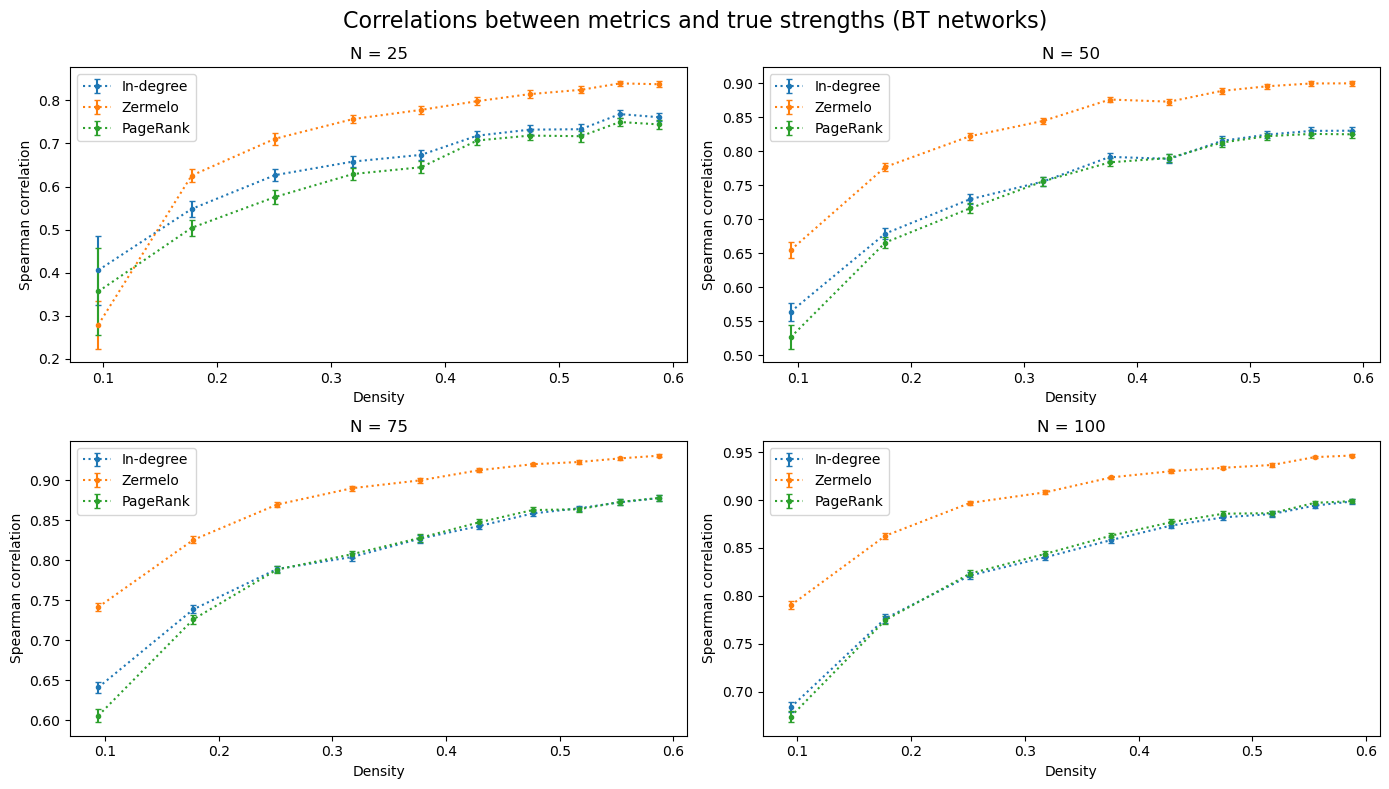

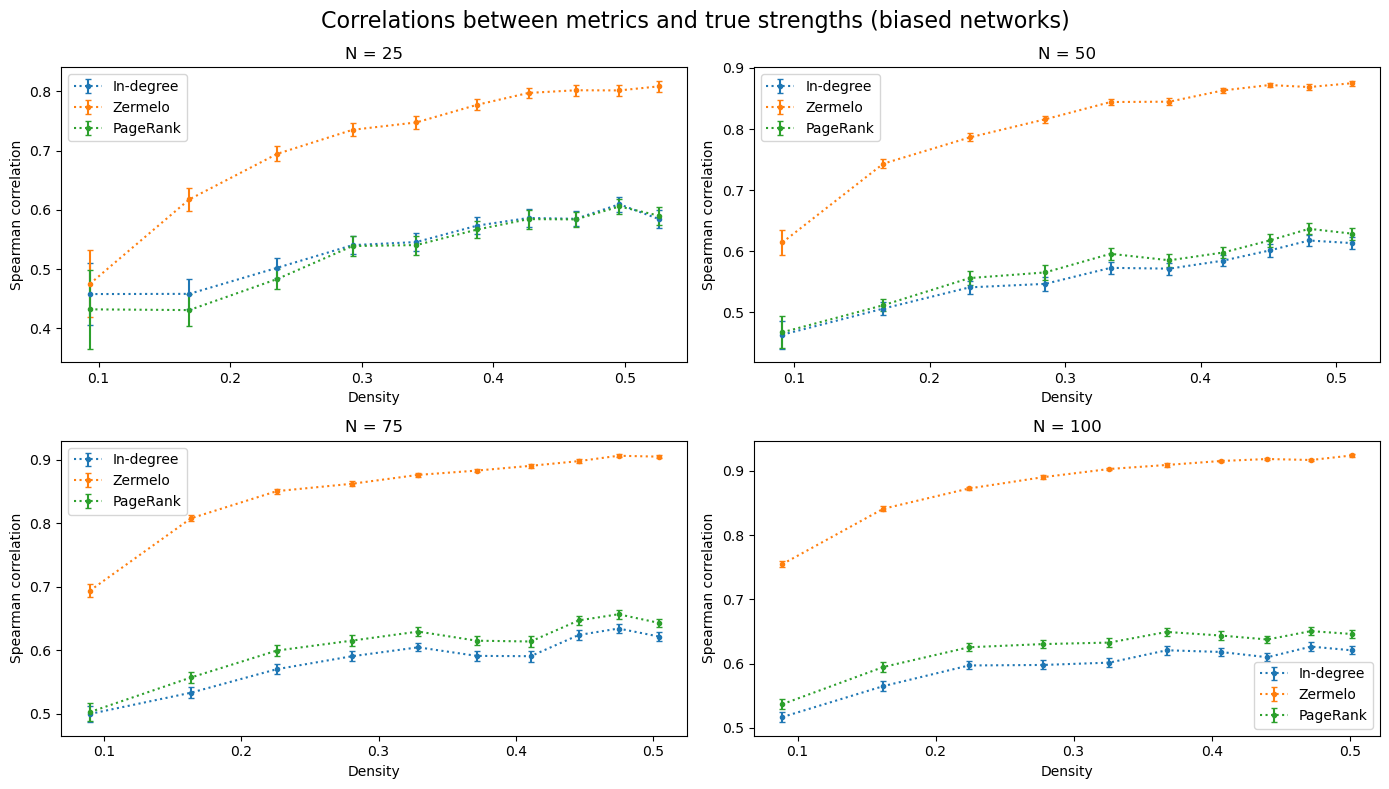

In [205]:
for type in ["BT", "biased"]:
    plt.figure(figsize=(14,8))
    alpha = alphas[2] # typical value for alpha: 0.15

    for i, N in enumerate(list_N):
        plt.subplot(2,2,i+1)
        
        plt.errorbar(all_results[type][N]["densities"], all_results[type][N]["in_degree"]["mean"], yerr=all_results[type][N]["in_degree"]["error"], label="In-degree", marker=".", linestyle=":", capsize=2)
        plt.errorbar(all_results[type][N]["densities"], all_results[type][N]["zermelo"]["mean"], yerr=all_results[type][N]["zermelo"]["error"], label="Zermelo", marker=".", linestyle=":", capsize=2)
        plt.errorbar(all_results[type][N]["densities"], all_results[type][N]["pagerank"][alphas[2]]["mean"], yerr=all_results[type][N]["pagerank"][alphas[2]]["error"], label="PageRank", marker=".", linestyle=":", capsize=2)

        plt.title(f"N = {N}")
        plt.xlabel("Density")
        plt.ylabel("Spearman correlation")
        plt.legend()

    plt.suptitle(f"Correlations between metrics and true strengths ({type} networks)", fontsize=16)
    plt.tight_layout()
    plt.show()


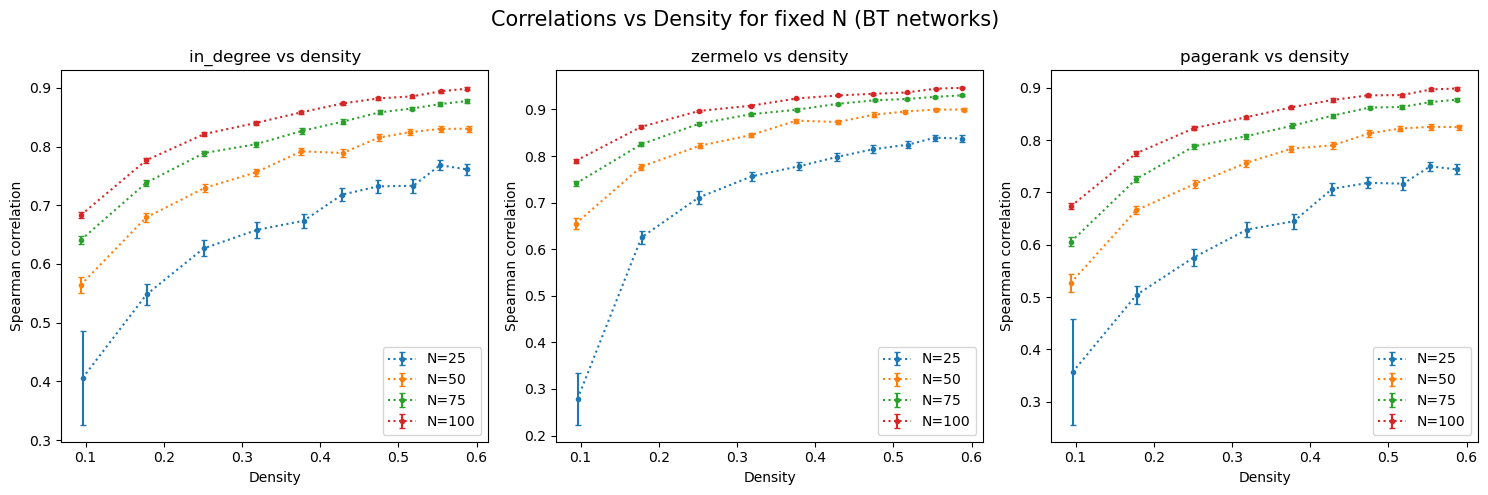

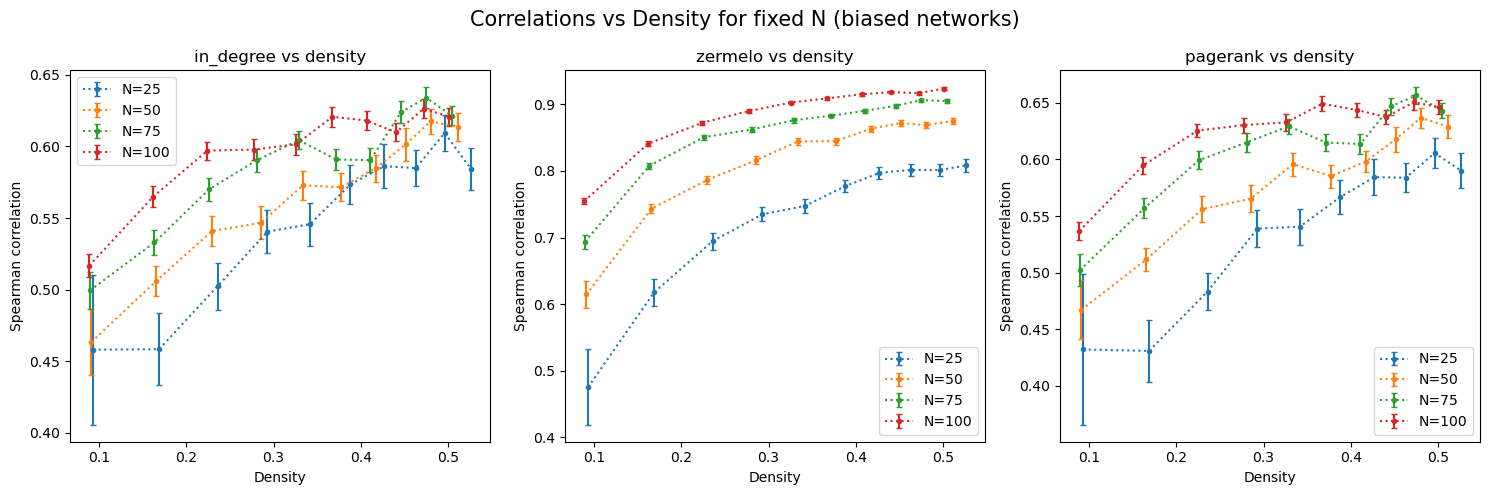

In [195]:
metrics = ["in_degree", "zermelo", "pagerank"]
alpha = alphas[2]

for network_type in ["BT", "biased"]:
    plt.figure(figsize=(15, 5))

    for j,metric in enumerate(metrics):
        plt.subplot(1,3,j+1)

        for N in list_N:
            data_N=all_results[network_type][N]

            if metric == "pagerank":
                means = data_N["pagerank"][alpha]["mean"]
                errors = data_N["pagerank"][alpha]["error"]

            else:
                means = data_N[metric]["mean"]
                errors = data_N[metric]["error"]

            plt.errorbar(data_N["densities"], means, yerr=errors, label=f"N={N}", marker=".", linestyle=":", capsize=2)
        
        plt.xlabel("Density")
        plt.ylabel("Spearman correlation")
        plt.title(f"{metric} vs density")
        plt.legend()


    plt.suptitle(f"Correlations vs Density for fixed N ({network_type} networks)", fontsize=15)
    plt.tight_layout()
    plt.show()

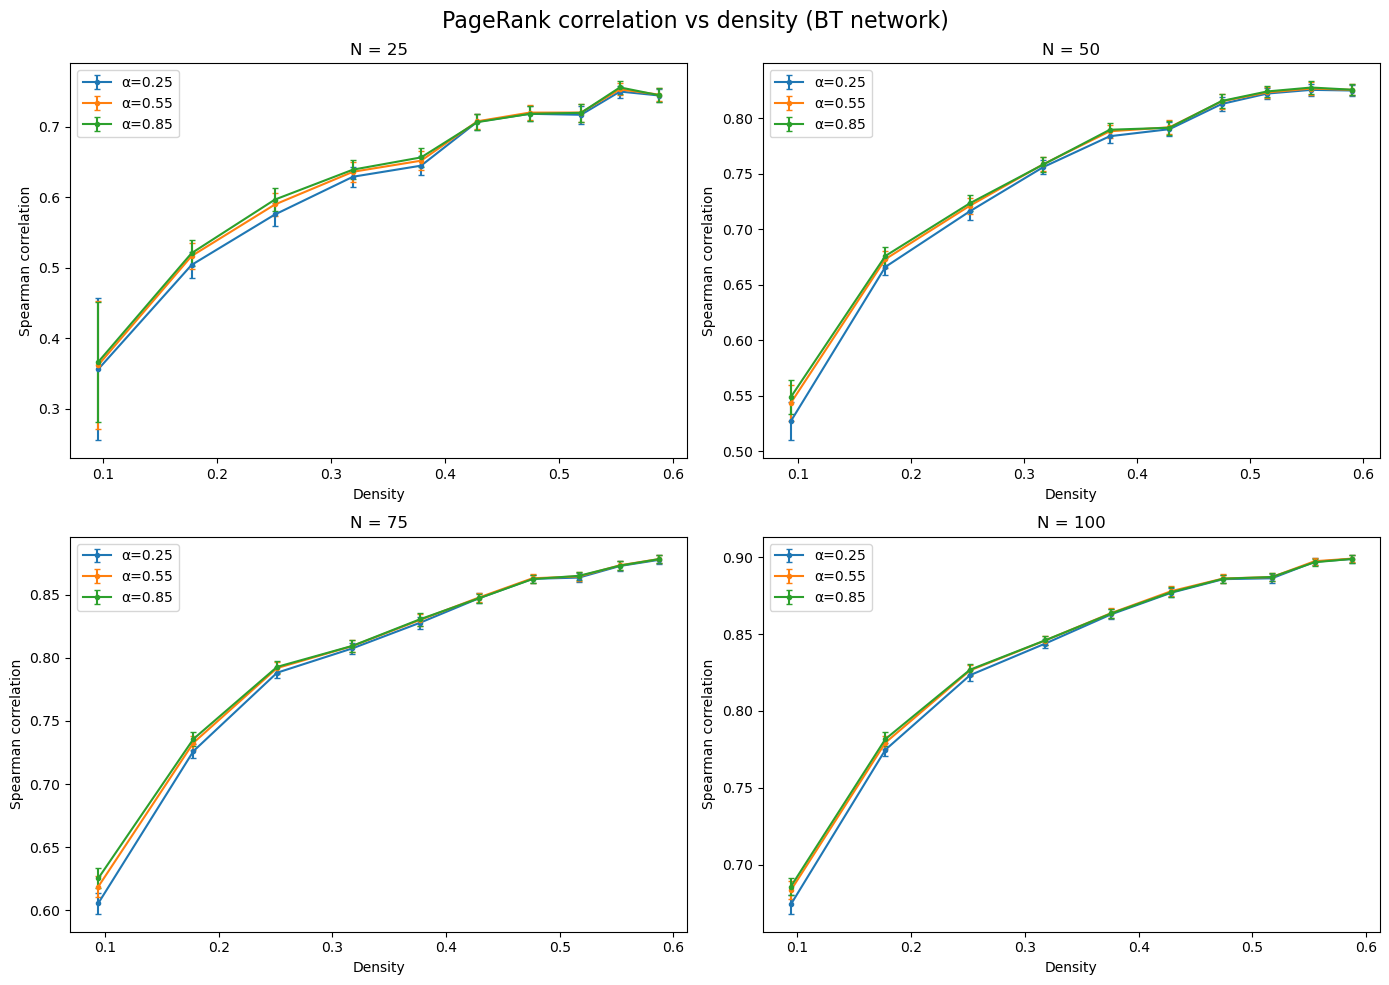

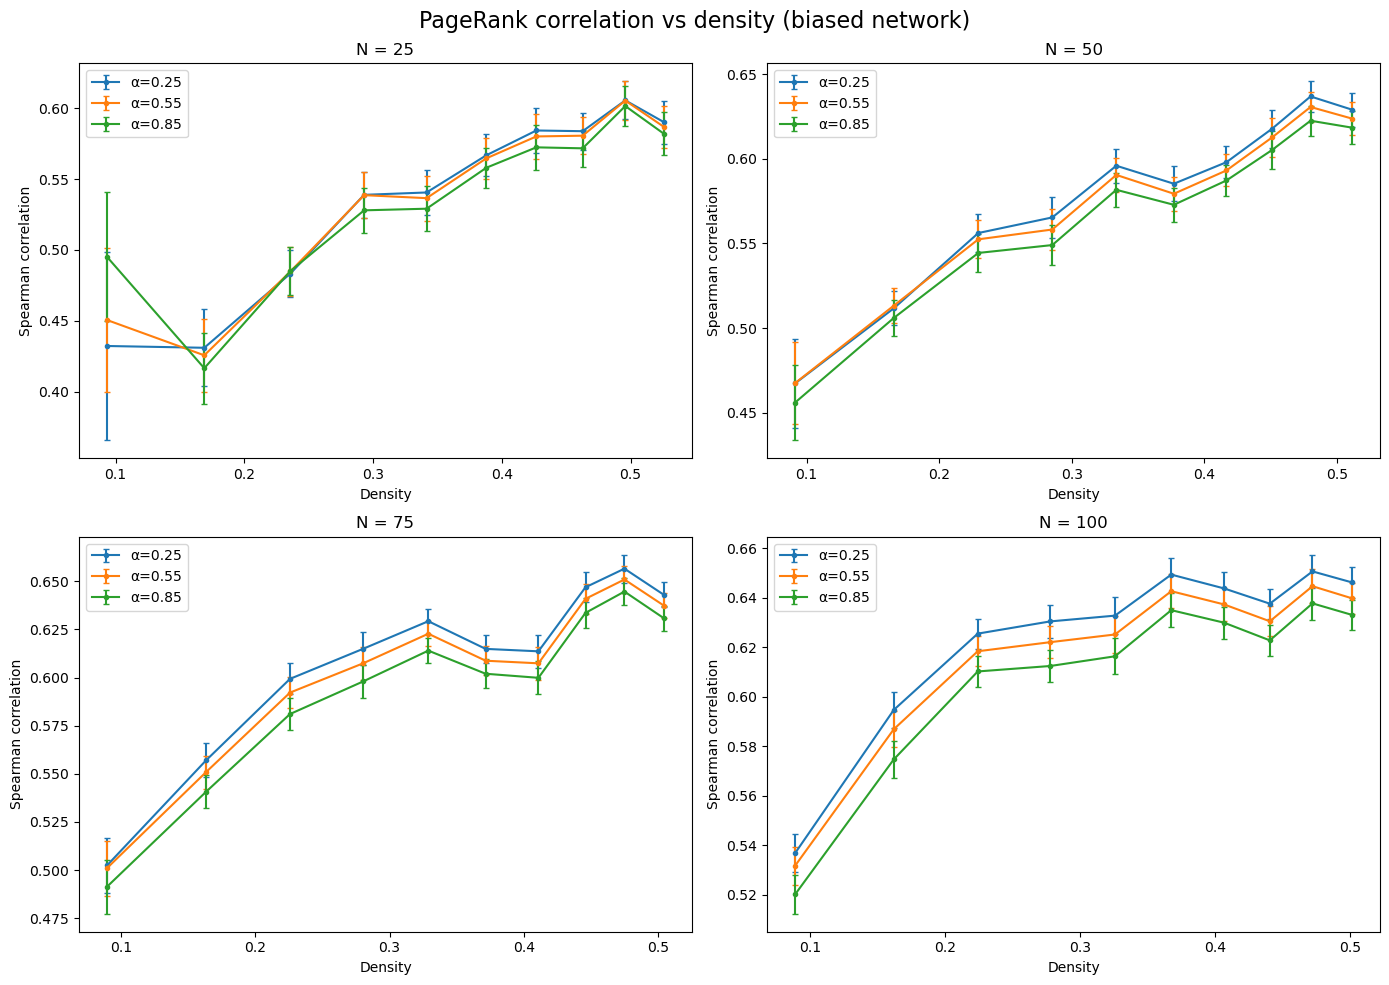

In [196]:
alpha_indices = [2,5,8]
s_alphas = alphas[alpha_indices]

for type in ["BT", "biased"]:
    plt.figure(figsize=(14, 10))

    for i, N in enumerate(list_N):

        plt.subplot(2, 2, i+1)
        data_N = all_results[type][N]

        for alpha in s_alphas:
            means = data_N["pagerank"][alpha]["mean"]
            errors = data_N["pagerank"][alpha]["error"]
            plt.errorbar(data_N["densities"], means, yerr=errors, marker=".", linestyle="-", capsize=2, label=f"α={alpha:.2f}")


        plt.xlabel("Density")
        plt.ylabel("Spearman correlation")
        plt.title(f"N = {N}")
        plt.legend()
    
    plt.suptitle(f"PageRank correlation vs density ({type} network)", fontsize=16)
    plt.tight_layout()
    plt.show()
        

## References

- **NetworkX documentation**,  
https://networkx.org/documentation/stable/tutorial.html, for understanding the basics of the library $\texttt{NetworkX}$ (26.09.2025)

- **PageRank algorithm**,  
https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html (29.09.2025)

- **Spearman and Pearson correlation**,  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html,  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html (30.09.2025)

- **KDE plot**,  
https://seaborn.pydata.org/generated/seaborn.kdeplot.html,  
https://www.geeksforgeeks.org/data-science/seaborn-kdeplot-a-comprehensive-guide (05.10.2025)

- **Box plot**,  
https://seaborn.pydata.org/generated/seaborn.boxplot.html,  
https://www.stat4decision.com/fr/le-box-plot-ou-la-fameuse-boite-a-moustache,  
https://www.geeksforgeeks.org/machine-learning/box-plot (05.10.2025)


In [197]:
end = time.time()
total_time = end-start

# Calculez les heures
heures = int(total_time // 3600)

# Calculez les minutes restantes
minutes = int((total_time % 3600) // 60)

# Calculez les secondes restantes
secondes = total_time % 60 

In [198]:
print(f"The code took {heures} hours, {minutes} minutes and {secondes} seconds.")

The code took 0 hours, 7 minutes and 22.043455362319946 seconds.
